# 데이터 시각화 — 인사이트를 도출하고 전달한다

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

# 📊 데이터를 '보는' 기술 — 시각화로 검증·탐색·전달하기

### — 차트 한 장이 회의를 바꾼다 —

---

## 📋 학습 목표

이 자습서를 마치면 여러분은 다음을 할 수 있습니다.

1. 차트를 그리기 전에 **검증·탐색·전달** 중 어떤 목적인지 먼저 정할 수 있습니다.
2. "무엇을 알고 싶은가"라는 질문에서 적절한 차트 유형을 골라낼 수 있습니다.
3. `missingno`로 결측치의 **개수**가 아닌 **패턴**을 한눈에 진단할 수 있습니다.
4. 전처리 전·후 분포를 겹쳐 그려 **처리가 의도대로 됐는지** 스스로 검증할 수 있습니다.
5. Seaborn으로 변수 간 관계·분포를 탐색해 **다음 분석 질문**을 도출할 수 있습니다.
6. Plotly 인터랙티브 차트로 동료가 직접 들여다볼 수 있는 **전달용 자료**를 만들 수 있습니다.
7. 차트를 그리기 전에 "이 그림으로 무엇을 판단할 것인가"를 먼저 묻는 습관을 들일 수 있습니다.

> 💡 위 목록을 천천히 읽고, 지금 내가 할 수 있는 것과 아직 낯선 것을 마음속으로 표시해보세요. 자습서를 다 마친 뒤 다시 돌아와 비교하면 여러분의 성장이 눈에 보일 거예요.

## 📚 목차

| Part | 내용 | 핵심 질문 |
| --- | --- | --- |
| Part 0 | 분석 상황과 학습 지도 | 오늘은 어떤 데이터로 무엇을 '보게' 될까요? |
| Part 1 | 차트의 세 가지 목적 | 같은 데이터, 왜 다른 차트가 필요할까요? |
| Part 2 | 결측 시각화 — missingno | 결측의 모양은 어떻게 생겼을까요? |
| Part 3 | 전·후 분포 비교 (검증) | 내 전처리가 의도대로 적용됐을까요? |
| Part 4 | Seaborn 관계·분포 탐색 | 정제된 데이터에서 어떤 패턴이 보일까요? |
| Part 5 | Plotly 인터랙티브 전달 | 동료가 직접 들여다보게 만들려면? |
| 종합 실습 | 검증 + 탐색 + 전달 통합 | 한 데이터셋을 끝까지 시각화로 풀어내볼까요? |
| 정리 | 핵심 요약 · 다음 시간 | 오늘 본 것이 내일 마무리에서 어떻게 쓰일까요? |

## 분석 상황과 학습 지도

# 0. 분석 상황과 학습 지도

## 지난 시간에는 무엇을 했나요?

바로 전 시간(D+007)에는 **대용량 데이터를 처리**하는 방법을 배웠습니다. pandas의 메모리 한계를 이해하고, `dtype` 최적화·청크 처리·Polars 같은 도구로 큰 데이터를 다뤘죠. "이 도구로 처리한 데이터, 결과를 어떻게 확인할까?"라는 질문이 자연스럽게 따라옵니다.

그 질문에 답하는 시간이 오늘입니다.

## 오늘 한 줄

> **차트를 그리기 전에, 먼저 묻습니다 — "이 차트로 무엇을 판단할 것인가?"**

같은 산점도라도 **"전처리가 잘 됐는지 검증"** 하려고 그리는 것과 **"새로운 패턴을 탐색"** 하려고 그리는 것은 다릅니다. 누구에게 보여줄지(나 vs 동료 vs 임원)에 따라 또 달라집니다. 오늘은 **목적 → 차트 선택** 의 논리를 다섯 가지 도구(matplotlib, seaborn, missingno, plotly)로 익힙니다.

## 오늘의 여정

```text
[Part 1] 차트 3목적              검증·탐색·전달, 무엇이 다른가
   ↓
[Part 2] 결측 시각화 (missingno)  개수가 아닌 '모양'을 본다
   ↓
[Part 3] 전·후 분포 비교         정제가 의도대로 됐는지 검증
   ↓
[Part 4] Seaborn 관계·분포 탐색   다음 질문을 만드는 그림
   ↓
[Part 5] Plotly 인터랙티브 전달   동료가 만지게 하는 차트
   ↓
[종합 실습] 한 데이터셋으로 검증 → 탐색 → 전달 → 인사이트 보고
```

## 이 자습서 사용법

- 📖 **읽고** — 개념 설명을 천천히 읽습니다.
- 💻 **실행하고** — 코드 셀을 위에서부터 순서대로 실행합니다. (`Shift + Enter`)
- ✏️ **고쳐보고** — "스스로 해보자!" 칸에서 코드를 직접 바꿔봅니다.
- 🤔 **답해보고** — 체크포인트 질문에 스스로 답해봅니다. 틀려도 괜찮습니다.

> ⚠ **주의:** 셀은 **위에서부터 순서대로** 실행해야 합니다. 중간을 건너뛰면 "앞에서 만든 변수가 없다"는 오류가 날 수 있어요. 오류는 잘못이 아니라 디버깅의 단서입니다.

## 오늘의 무대 — 다시 모두마켓

이 모듈 내내 분석해 온 가상 이커머스 **모두마켓** 데이터를 오늘도 씁니다. 단, 오늘은 데이터를 **두 가지 상태**로 갖고 시작합니다.

- `orders_raw` : 결측·이상치·표기 혼재 등 오염이 그대로 있는 **정제 전** 데이터
- `orders_clean` : 며칠 동안 배운 정제 기법을 적용한 **정제 후** 데이터

두 상태를 나란히 두는 이유는 단순합니다. **시각화의 첫 번째 쓰임이 "처리 전후 비교"** 이기 때문이에요. Part 3에서 본격적으로 다룹니다.

> ⚠️ **단독 실행 원칙:** 각 교안은 그날 쓸 데이터를 셀 하나로 새로 만들어 단독 실행되도록 구성합니다. 이전 노트북을 먼저 돌릴 필요가 없어요.

> **읽는 법:** 컬럼은 동일하지만 내용은 다릅니다. `orders_raw`에는 `channel`에 `'APP'`, `'app '`이 보이고, 일부 `amount`가 비어 있습니다. `orders_clean`에서는 `channel`이 소문자로 통일됐고 결측이 사라졌어요. 이렇게 두 버전을 같이 두면 **시각화로 "정말 의도대로 됐는가"를 검증** 할 수 있습니다.

이제 본격적으로 들어갑니다. 첫 질문은 "왜 시각화에도 *목적*이 따로 있어야 하는가" 입니다.

In [1]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 처음 실행하는 경우 아래 두 줄의 주석을 풀어 설치하세요.
%pip install missingno plotly -q

import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import plotly.express as px
import plotly.io as pio

warnings.filterwarnings("ignore")
np.random.seed(42)

# 한글 폰트 (운영체제별 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

# Plotly는 환경에 따라 기본 렌더러가 다릅니다.
# 노트북에서 인터랙티브로 보이도록 명시적으로 지정합니다.
try:
    pio.renderers.default = "notebook"
except Exception:
    pass

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("pandas    :", pd.__version__)
print("seaborn   :", sns.__version__)
print("missingno :", msno.__version__ if hasattr(msno, "__version__") else "(installed)")

Note: you may need to restart the kernel to use updated packages.
준비 완료! 라이브러리 버전을 확인합니다.
pandas    : 3.0.3
seaborn   : 0.13.2
missingno : 0.5.2


In [2]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 — 정제 전(raw)과 정제 후(clean) 두 버전
# ─────────────────────────────────────────────
np.random.seed(42)

# 1) 고객
n_customers = 500
customers = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(4)}" for i in range(1, n_customers + 1)],
    "age": np.random.normal(35, 9, n_customers).round().astype(int),
    "gender": np.random.choice(["M", "F"], n_customers),
    "region": np.random.choice(["서울", "경기", "부산", "인천", "대구"], n_customers),
    "membership": np.random.choice(["basic", "premium", "vip"], n_customers, p=[0.6, 0.3, 0.1]),
})
# 일부러 심은 오염
customers.loc[5, "age"] = 999
customers.loc[10, "age"] = -3
customers.loc[[20, 21, 22, 23], "gender"] = np.nan
customers.loc[30, "region"] = " 서울 "

# 2) 상품
categories = ["패션", "뷰티", "식품", "가전", "도서"]
products = pd.DataFrame({
    "product_id": [f"P{str(i).zfill(3)}" for i in range(1, 41)],
    "category": np.random.choice(categories, 40),
    "price": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], 40),
})

# 3) 주문 — 정제 전 버전
n_orders = 3000
order_customer = np.random.choice(customers["customer_id"], n_orders)
order_product = np.random.choice(products["product_id"], n_orders)
price_map = products.set_index("product_id")["price"]
quantity = np.random.choice([1, 1, 1, 2, 2, 3], n_orders)
amount = price_map.loc[order_product].values * quantity

orders_raw = pd.DataFrame({
    "order_id": [f"O{str(i).zfill(5)}" for i in range(1, n_orders + 1)],
    "customer_id": order_customer,
    "product_id": order_product,
    "quantity": quantity.astype(float),
    "amount": amount.astype(float),
    "channel": np.random.choice(["web", "app", "app ", "APP"], n_orders, p=[0.45, 0.45, 0.05, 0.05]),
})

# 의도적 오염: amount의 일부는 결측(특히 web 채널에서 더 자주 결측 — MAR 패턴)
web_mask = orders_raw["channel"] == "web"
web_idx = orders_raw[web_mask].sample(150, random_state=1).index
other_idx = orders_raw[~web_mask].sample(40, random_state=1).index
orders_raw.loc[web_idx, "amount"] = np.nan
orders_raw.loc[other_idx, "amount"] = np.nan

# quantity 이상치
orders_raw.loc[7, "quantity"] = 100
orders_raw.loc[123, "quantity"] = 80

# amount 이상치(VIP 한 명의 대량 구매)
orders_raw.loc[200, "amount"] = 5_000_000

# 중복 행
orders_raw = pd.concat([orders_raw, orders_raw.iloc[[0, 1, 2]]], ignore_index=True)

# 날짜 — 일부 포맷 혼재
base_dates = pd.to_datetime("2025-01-01") + pd.to_timedelta(
    np.random.randint(0, 120, len(orders_raw)), unit="D"
)
orders_raw["order_date"] = base_dates

# 4) 정제 후 버전 — D+003~D+007에서 배운 기법을 적용했다고 가정
orders_clean = orders_raw.copy()
# (a) 중복 제거
orders_clean = orders_clean.drop_duplicates(subset="order_id").reset_index(drop=True)
# (b) channel 표기 통일
orders_clean["channel"] = orders_clean["channel"].str.strip().str.lower()
# (c) quantity 이상치를 IQR 기준 상한으로 클리핑
q1, q3 = orders_clean["quantity"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
orders_clean.loc[orders_clean["quantity"] > upper, "quantity"] = upper
# (d) amount 결측은 'product_id 평균 단가 × 수량'으로 대체
mean_unit_price = (orders_clean.dropna(subset=["amount"])
                   .assign(unit=lambda d: d["amount"] / d["quantity"])
                   .groupby("product_id")["unit"].mean())
need_fill = orders_clean["amount"].isna()
orders_clean.loc[need_fill, "amount"] = (
    orders_clean.loc[need_fill, "product_id"].map(mean_unit_price)
    * orders_clean.loc[need_fill, "quantity"]
)
# (e) amount 극단 이상치도 99% 분위수로 클리핑
cap = orders_clean["amount"].quantile(0.99)
orders_clean.loc[orders_clean["amount"] > cap, "amount"] = cap

print("정제 전 :", orders_raw.shape, "결측 amount:", orders_raw["amount"].isna().sum())
print("정제 후 :", orders_clean.shape, "결측 amount:", orders_clean["amount"].isna().sum())

정제 전 : (3003, 7) 결측 amount: 189
정제 후 : (3000, 7) 결측 amount: 0


In [3]:
# 두 데이터의 머리 부분을 한 번씩 보고, 컬럼이 같은지 확인합니다.
print("[orders_raw]")
display(orders_raw.head(3))
print("[orders_clean]")
display(orders_clean.head(3))

[orders_raw]


,order_id,customer_id,product_id,quantity,amount,channel,order_date
0,O00001,C0149,P018,1.0,49900.0,app,2025-03-08
1,O00002,C0126,P002,1.0,49900.0,web,2025-03-07
2,O00003,C0392,P008,2.0,99800.0,web,2025-02-21


[orders_clean]


,order_id,customer_id,product_id,quantity,amount,channel,order_date
0,O00001,C0149,P018,1.0,49900.0,app,2025-03-08
1,O00002,C0126,P002,1.0,49900.0,web,2025-03-07
2,O00003,C0392,P008,2.0,99800.0,web,2025-02-21


## 차트의 세 가지 목적 — 검증·탐색·전달

# 1. 차트의 세 가지 목적 — 검증·탐색·전달

D+002에서 우리는 "분포·관계·추이·비교"라는 **질문 유형**으로 차트를 골랐습니다. 잘 작동하는 분류였죠. 그런데 같은 산점도라도 **누가, 왜** 보느냐에 따라 그리는 방식이 달라집니다. 데이터 분석가의 일상에서 차트는 보통 다음 셋 중 하나의 역할을 합니다.

> ❓ **이 파트에서 답할 질문:** 차트를 그리기 전에, 우리는 무엇을 **먼저** 결정해야 할까요?

## 💡 쉽게 말하면 — 같은 데이터, 세 가지 쓸모

```text
[검증 Verify]
  "내가 한 처리, 의도대로 됐나?" → 정제 전·후 두 분포를 겹쳐 그리기
  대상: 나 자신, 동료 분석가
  핵심: 비교 / 차이를 잘 보이게 / 깔끔한 정적 차트면 충분

[탐색 Explore]
  "여기서 또 다른 패턴이 보이나?" → 이리저리 굴려보며 새 질문 만들기
  대상: 나 자신
  핵심: 많이 / 빠르게 / 의외성을 잡아낸다 (pairplot, heatmap 등)

[전달 Communicate]
  "동료/임원이 들여다보게 만들기" → 한 그림으로 메시지 한 줄
  대상: 동료 분석가가 아닌 사람
  핵심: 한 차트 한 메시지 / 라벨·제목·범례·인터랙션
```

세 가지를 한 차트에 다 담으려는 시도는 거의 실패합니다. **누가 보느냐**가 차트를 바꿉니다.

## 자세히 알아보기

| 목적 | 우선 가치 | 추천 도구 | 본문 Part |
| --- | --- | --- | --- |
| 검증(Verify) | 비교 가능성 · 정확성 | matplotlib + Seaborn (정적) | Part 3 |
| 탐색(Explore) | 빠르고 다양하게 | Seaborn pairplot · heatmap | Part 4 |
| 전달(Communicate) | 한 메시지 · 인터랙션 | Plotly · 잘 다듬은 Seaborn | Part 5 |

## 데이터로 확인해 봅시다

분석가의 하루는 보통 이렇게 흐릅니다.

1. (탐색) 처음 보는 데이터를 이리저리 그려본다 → 새 질문이 떠오른다
2. (검증) 그 질문에 답하려고 정제·처리를 한다 → 의도대로 됐는지 그려본다
3. (전달) 결론이 나면, 동료/임원에게 한 장으로 보여줄 차트를 다듬는다

세 단계 모두 시각화가 들어가지만 **목적이 다르면 그리는 방식도 달라야** 합니다.

## 차트 선택 결정 트리

목적이 정해졌다면, 그 다음은 *질문 유형*입니다. 다음 결정 트리를 따라가며 선택해보세요.

```text
1) 이 차트의 목적은?
   ├─ 검증(Verify)        → 전·후 비교가 가능한가? → KDE 겹쳐 / boxplot side-by-side
   ├─ 탐색(Explore)       → 한 변수? 두 변수? 다변량?
   │     ├─ 한 변수       → histplot / kdeplot / boxplot
   │     ├─ 두 변수       → scatterplot / regplot / heatmap(상관)
   │     └─ 다변량        → pairplot / facet plot (sns.FacetGrid)
   └─ 전달(Communicate)   → 청중이 만지나? 인쇄되나?
         ├─ 노트북·웹     → Plotly (interactive)
         └─ PDF·인쇄·발표 → matplotlib (정적·큰 라벨)

2) 무엇을 알고 싶은가?
   ├─ 분포     → histplot, kdeplot, boxplot, violinplot
   ├─ 관계     → scatterplot, regplot, heatmap
   ├─ 추이     → lineplot, px.line
   └─ 비교     → barplot, countplot
```

이 트리는 외울 필요 없습니다. **"목적부터 묻는다"** 한 습관만 지키면, 나머지는 데이터를 보다가 자연스럽게 따라옵니다.

> 📌 **다른 산업에서는?** 같은 셋이 반복됩니다. 마케팅은 A/B 테스트 결과 *검증* → 새 캠페인 후보 *탐색* → 임원에게 결과 *전달*. 금융은 신용 점수 모델 *검증* → 위험 변수 *탐색* → 규제기관에 *전달*. 헬스케어는 임상 데이터 *검증* → 부작용 신호 *탐색* → 의료진에게 *전달*. 산업이 달라도 시각화의 세 쓸모는 같습니다.

> 💡 **더 알고 싶다면:** "한 차트 한 메시지"라는 원칙이 있습니다. 한 차트에 두 가지 이야기를 담으려고 하면 둘 다 흐려져요. 메시지가 두 개라면 차트도 두 개로 나누는 편이 거의 항상 낫습니다. 발표 자료를 다듬을 때 이 원칙을 자주 떠올리게 될 거예요.

> **읽는 법:** 세 그림이 다 같은 `orders` 데이터에서 왔지만, 답하는 질문이 다릅니다. 왼쪽은 "정제가 됐나?"(검증), 가운데는 "어디 더 봐야 할까?"(탐색), 오른쪽은 "한 줄 메시지는?"(전달)에 답합니다. **목적이 정해진 뒤에야 차트 모양이 정해진다** 는 게 오늘의 핵심입니다.

### 스스로 해보자! ✏️ (1)

> 정답은 하나가 아닙니다. 일단 실행해보세요.

다음 상황을 보고, 각각 어떤 목적(검증·탐색·전달)에 해당하는지 적어보세요.

1. 결측치를 평균으로 대체한 뒤, 대체 전후 분포가 비슷한지 확인하려고 두 히스토그램을 겹쳐 그렸다.
2. 처음 보는 데이터의 모든 수치 변수 쌍을 한 번에 산점도로 그려보았다.
3. 다음 주 임원 회의용으로, "VIP 고객 매출이 전체의 40%를 차지한다"는 한 줄을 보여주는 막대 그래프를 다듬었다.

### ✅ 짚고 넘어가기

1. 같은 산점도라도 그리는 목적이 다를 수 있는 이유를 한 줄로 말할 수 있나요?
2. 탐색용 차트와 전달용 차트의 가장 큰 차이는 무엇인가요?
3. "검증용 차트"가 가져야 할 가장 중요한 성질은 무엇이라고 생각하나요?

> 💡 **다음 Part 예고:** 검증의 시작은 결측 진단입니다. 그런데 결측치 *개수*만 세서는 보이지 않는 것이 있어요 — 결측의 **모양**(어디에, 같이 비는가)입니다. 다음 Part에서 `missingno`로 결측의 모양을 봅니다.

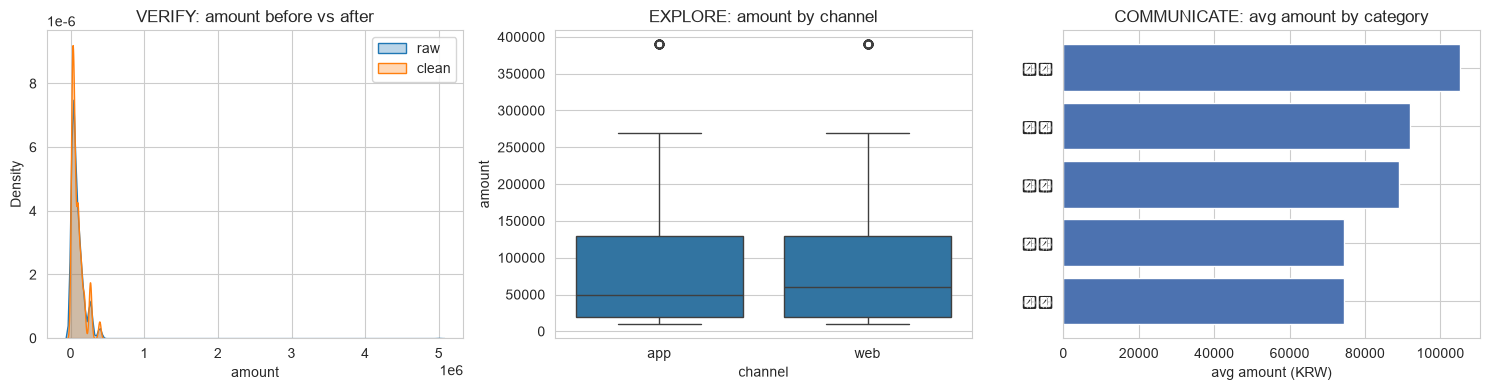

In [4]:
# 같은 데이터, 다른 목적 — 세 가지 그림으로 보여주기 (맛보기)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (검증) 정제 전·후 amount 분포 겹쳐 그리기
sns.kdeplot(orders_raw["amount"].dropna(), ax=axes[0], label="raw", fill=True, alpha=0.3)
sns.kdeplot(orders_clean["amount"], ax=axes[0], label="clean", fill=True, alpha=0.3)
axes[0].set_title("VERIFY: amount before vs after")
axes[0].legend()

# (탐색) channel별 amount 박스 — 어떤 채널이 큰 금액?
sns.boxplot(data=orders_clean, x="channel", y="amount", ax=axes[1])
axes[1].set_title("EXPLORE: amount by channel")

# (전달) 카테고리별 평균 매출 — 한 메시지
cat_sales = (orders_clean.merge(products, on="product_id")
             .groupby("category")["amount"].mean().sort_values())
axes[2].barh(cat_sales.index, cat_sales.values, color="#4C72B0")
axes[2].set_title("COMMUNICATE: avg amount by category")
axes[2].set_xlabel("avg amount (KRW)")

plt.tight_layout(); plt.show()

In [5]:
# 스스로 해보자! (1) — 머릿속으로 답한 뒤 아래 한 줄에 적어보세요.
# 1) 검증 -> 정제 전후 데이터 비교
# 2) 탐색 -> 한눈에 변수의 모습 확인하기 위한 산점도
# 3) 전달 -> 임원 전달용

## 결측 시각화 — `missingno`로 결측의 '모양'을 본다

# 2. 결측 시각화 — `missingno`로 결측의 '모양'을 본다

D+003에서 결측을 `isnull().sum()`으로 *개수*를 세고, `missingno`의 `bar`·`matrix`로 결측의 *모양*을 처음 들여다봤습니다. 그때는 진단의 일부였지만, 오늘은 시각화 자체를 더 깊게 활용합니다 — 특히 **두 컬럼이 *함께* 비는가**(`heatmap`), **정렬을 바꿔 보면 패턴이 어떻게 달라지는가**까지요. 진짜 위험한 결측은 **개수가 아닌 패턴**에서 드러나기 때문입니다.

> ❓ **이 파트에서 답할 질문:** 결측치는 **어디에, 누구와 함께** 비어 있는가? 그 모양을 어떻게 한눈에 볼까요?

## 💡 쉽게 말하면 — 결측 패턴 세 가지 풍경

```text
1) 무작위로 흩어진 결측        →  특정 채널·시간대에 몰리지 않음 (MCAR에 가까움)
2) 한 컬럼에 띠처럼 몰린 결측  →  그 컬럼만의 수집 문제 (MNAR 가능성)
3) 두 컬럼이 같이 비어 있음    →  같은 원인(시스템 장애 등)으로 결측 (MAR/MNAR)
```

같이 비는지 여부는 **결측 처리 전략**을 바꿉니다. 같이 비는 두 컬럼을 *각각* 평균 대체하면 둘 사이의 관계가 망가지기 때문이에요.

## 자세히 알아보기 — `missingno` 3종 세트

| 함수 | 무엇을 보여주나 | 언제 쓰나 |
| --- | --- | --- |
| `msno.bar(df)` | 컬럼별 *non-null* 비율 막대 | 결측이 많은 컬럼을 한눈에 |
| `msno.matrix(df)` | 행 순서대로 결측 위치를 검정 줄로 표시 | 결측이 시간/순서에 몰렸는지 |
| `msno.heatmap(df)` | 두 컬럼이 *같이* 결측되는 정도(상관) | 같은 원인으로 함께 비는가 |

> 💡 **개념 연결:** `isnull().sum()`이 *개수*, `missingno`가 *패턴*입니다. 둘 다 봐야 처리 전략을 옳게 정합니다. D+003에서 `bar`·`matrix`를 짧게 만났고, 오늘은 **`heatmap`을 본격적으로** + 정렬을 바꿔 보는 활용까지 깊게 다룹니다.

표만으로는 "amount가 190개 비어 있다"까지만 알 수 있습니다. 이 결측이 *어디에 몰려 있는지*는 다음 그림이 보여줍니다.

> **읽는 법:** 막대 높이가 1.0(=100%)에 가까우면 거의 결측이 없다는 뜻입니다. `amount` 막대가 다른 컬럼보다 낮으면 그 컬럼에 결측이 몰려 있다는 신호예요. 표로 본 숫자가 그림으로 직관화된 거죠.

> **읽는 법:** 검은색 영역이 비결측, 흰색 줄이 결측 위치입니다. `amount` 컬럼에 흰 줄이 *무작위로* 흩뿌려져 있으면 MCAR(완전 무작위 결측)에 가깝습니다. 만약 위쪽 절반이나 아래쪽 절반에 몰려 있다면, **수집 시기/순서**가 결측과 관련됐다는 단서가 됩니다.

> 📌 **실무 포인트:** matrix는 **행 순서에 따른 패턴**을 보여주므로, 데이터를 **시간순으로 정렬한 뒤** 그리면 "어느 시점부터 결측이 늘었는가"가 시각적으로 잡힙니다.

정렬 전후를 비교해보세요. 시간순으로 정렬했을 때 결측이 더 군집되어 보인다면 "**특정 시기에 시스템 장애로 결측이 생겼다**"는 가설을 세울 수 있습니다.

> **읽는 법:** 값이 **+1에 가까우면** 두 컬럼이 *함께* 결측되는 경향이 강하다는 뜻입니다. **-1에 가까우면** 한쪽이 비면 다른 쪽은 채워져 있다는 뜻이고요. 0 근처면 서로 무관합니다. 함께 비는 쌍이 보이면, *같은 원인*(예: 같은 폼/같은 API)으로 결측이 생긴다고 의심합니다. — 우리 데이터는 `amount`만 결측이라 다른 컬럼과의 상관은 거의 0이지만, 실제 데이터에서는 이 히트맵이 결측 처리 전략의 결정적 단서가 됩니다.

heatmap이 더 의미 있게 보이려면 결측이 *여러 컬럼에 동시에* 있어야 합니다. 다음 셀에서 일부러 두 컬럼이 같이 비는 작은 예제 데이터를 만들어 보여드릴게요.

> **읽는 법:** `phone`-`email` 칸이 1.0에 가까운 진한 색이 나오면, 둘이 *같이* 비는 경향이라는 뜻입니다. 이 경우 둘을 *각각* 평균 대체하면 두 변수 사이의 관계 신호를 잃습니다. 처리 전략은 (a) 함께 비는 행을 함께 처리, 또는 (b) "결측 자체를 새 변수(flag)로 남기기" 입니다.

## 데이터로 확인해 봅시다

- **개수→패턴→전략**: `isnull().sum()`으로 비율을 확인하고, `missingno`로 패턴을 보고, 그 패턴에 맞춰 처리 전략(삭제/대체/모델 기반 채움)을 선택합니다.
- **D+003의 MCAR/MAR/MNAR 분류**가 이 그림들로 한층 또렷해집니다. matrix가 무작위면 MCAR 후보, 한 컬럼에만 몰려 있으면 MNAR 후보, 두 컬럼이 같이 비면 MAR 후보입니다.

> 📌 **다른 산업에서는?** 임상 데이터에서 "환자가 항목을 비워둔 데에는 이유가 있다"가 헬스케어의 격언입니다. 설문조사에서는 민감 항목(소득)이 자주 비어 같이 묶입니다. 모두 missingno의 matrix·heatmap으로 신호를 잡아냅니다.

> 💡 **더 알고 싶다면:** `msno.dendrogram(df)`은 결측 패턴이 비슷한 컬럼끼리 묶어 트리로 그려줍니다. 컬럼이 많을 때 "비슷하게 비는 그룹"을 자동으로 찾는 데 유용해요.

### 스스로 해보자! ✏️ (2)

> 정답은 하나가 아닙니다. 일단 실행해보세요.

`customers` 데이터에는 `gender`에 몇 개의 결측이 있습니다.

1. **(따라하기)** `customers`에 대해 `msno.bar`와 `msno.matrix`를 각각 그려보세요.
2. **(응용)** matrix를 보고 결측이 **위쪽 몇 개 행에만 몰려** 있다면, 어떤 가설을 세울 수 있을까요?
3. **(생각해보기)** 만약 결측이 너무 적어(예: 0.5%) bar가 거의 1.0이라면, `missingno`를 굳이 그릴 필요가 있을까요?

<details>
<summary>💡 힌트 (클릭)</summary>

```python
msno.bar(customers, color="#55A868", figsize=(8, 3)); plt.show()
msno.matrix(customers, color=(0.33, 0.66, 0.41), figsize=(8, 3)); plt.show()

# 2) "초기 입력 폼에 버그가 있었다" 같은 가설을 세우고, 시기와 짝지어 검증합니다.
# 3) 결측이 매우 적으면 bar만으로 충분합니다. 패턴이 보일 만큼이 안 되니까요.
```

</details>

### ✅ 짚고 넘어가기

1. `missingno`의 `bar`·`matrix`·`heatmap`은 각각 무엇을 보여주나요?
2. `matrix`를 시간순으로 정렬하고 그리는 이유는 무엇인가요?
3. heatmap에서 값이 +1에 가까운 두 컬럼은 어떤 처리 전략을 함께 고려해야 할까요?

> 💡 **다음 Part 예고:** 결측의 모양을 봤다면, 이제 **결측을 채운 결과가 의도대로 됐는지** 검증할 차례입니다. 다음 Part에서 정제 전·후 분포를 겹쳐 그려 검증합니다.

In [6]:
# 결측 진단의 출발 — 표로도 한 번 확인합니다.
print("[orders_raw 결측 개수]")
print(orders_raw.isnull().sum())
print("\n[orders_raw 결측 비율 %]")
print((orders_raw.isnull().mean() * 100).round(1))

[orders_raw 결측 개수]
order_id         0
customer_id      0
product_id       0
quantity         0
amount         189
channel          0
order_date       0
dtype: int64

[orders_raw 결측 비율 %]
order_id       0.0
customer_id    0.0
product_id     0.0
quantity       0.0
amount         6.3
channel        0.0
order_date     0.0
dtype: float64


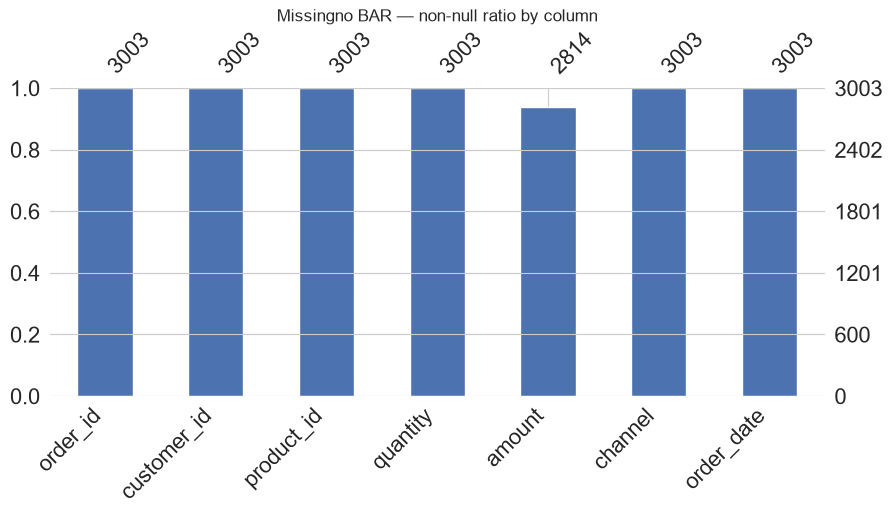

In [7]:
# 1) bar — 컬럼별 비결측 비율
msno.bar(orders_raw, color="#4C72B0", figsize=(10, 4))
plt.title("Missingno BAR — non-null ratio by column")
plt.show()

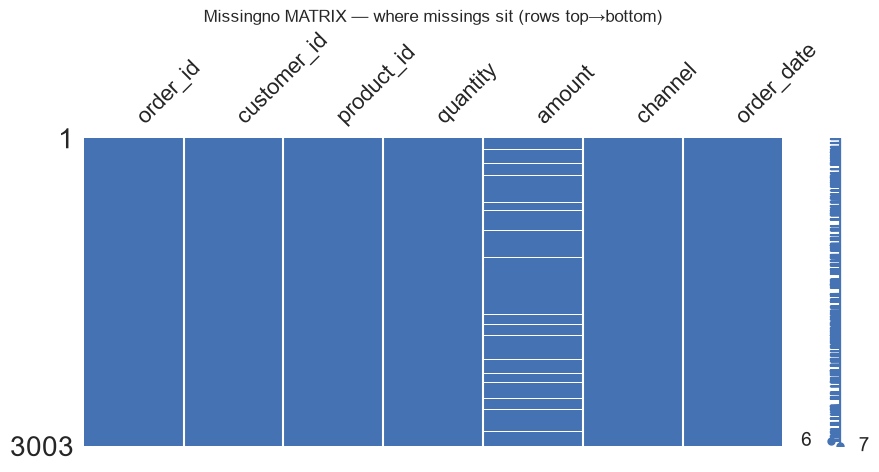

In [8]:
# 2) matrix — 결측 위치 패턴
msno.matrix(orders_raw, color=(0.27, 0.45, 0.70), figsize=(10, 4))
plt.title("Missingno MATRIX — where missings sit (rows top→bottom)")
plt.show()

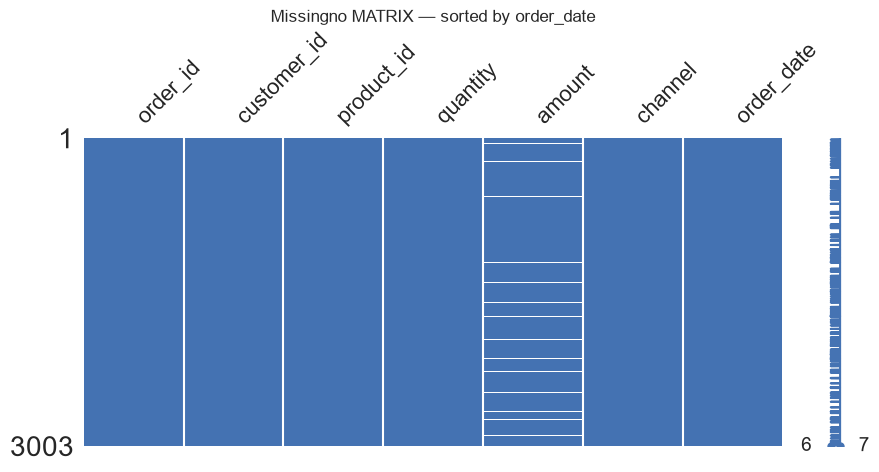

In [9]:
# matrix를 더 의미 있게: 날짜순으로 정렬한 뒤 다시 그리기
sorted_raw = orders_raw.sort_values("order_date")
msno.matrix(sorted_raw, color=(0.27, 0.45, 0.70), figsize=(10, 4))
plt.title("Missingno MATRIX — sorted by order_date")
plt.show()

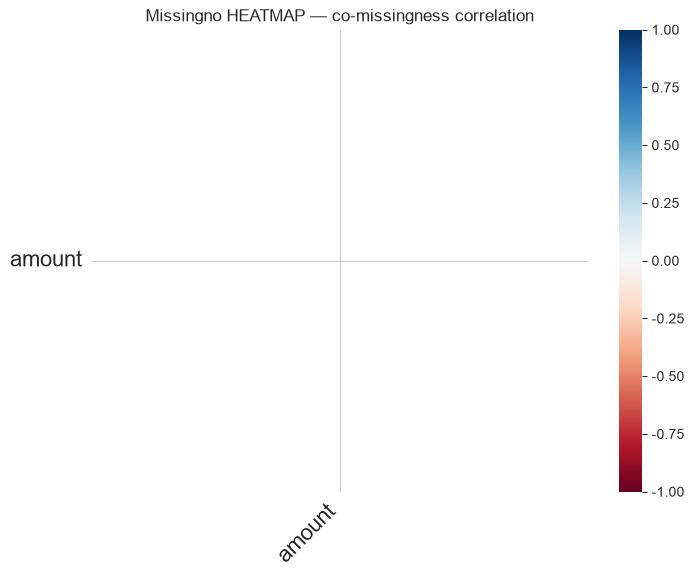

In [10]:
# 3) heatmap — 두 컬럼이 같이 비는가? (결측 상관)
msno.heatmap(orders_raw, figsize=(8, 6))
plt.title("Missingno HEATMAP — co-missingness correlation")
plt.show()

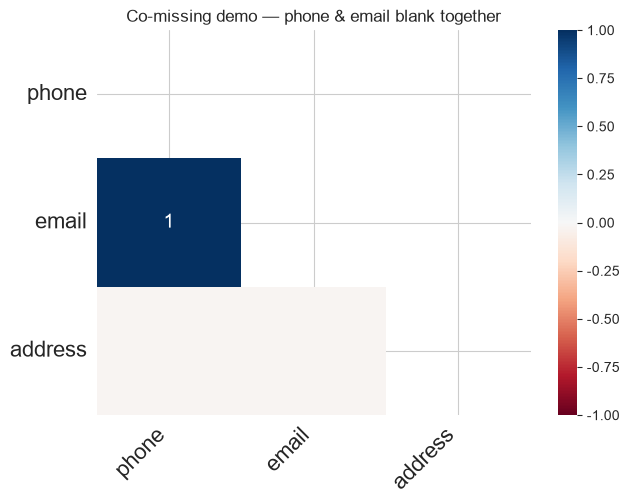

In [11]:
# 결측 공출현(co-missing) 시뮬레이션 — heatmap이 빛을 발하는 상황
np.random.seed(0)
n = 500
demo = pd.DataFrame({
    "phone":   np.random.randint(1000, 9999, n).astype(float),
    "email":   np.random.randint(1000, 9999, n).astype(float),
    "address": np.random.randint(1000, 9999, n).astype(float),
    "age":     np.random.randint(20, 60, n).astype(float),
})
# 시나리오: phone과 email이 같은 입력 폼에서 받아져, 같이 비는 일이 잦다.
co_idx = np.random.choice(n, 60, replace=False)
demo.loc[co_idx, "phone"] = np.nan
demo.loc[co_idx, "email"] = np.nan          # 같이 비움 → 강한 양의 상관
# address는 독립적으로 비움
demo.loc[np.random.choice(n, 50, replace=False), "address"] = np.nan

msno.heatmap(demo, figsize=(7, 5))
plt.title("Co-missing demo — phone & email blank together"); plt.show()

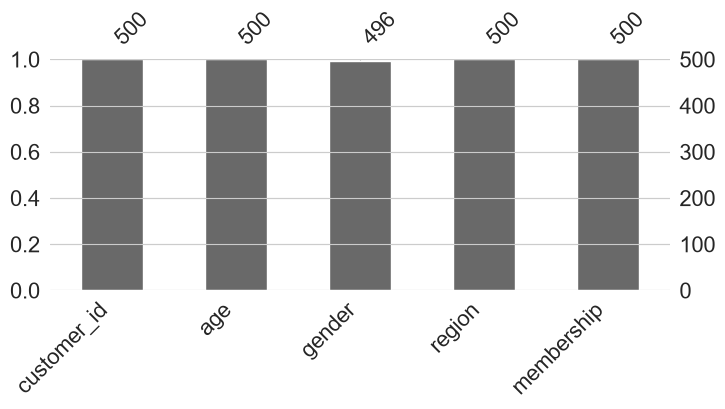

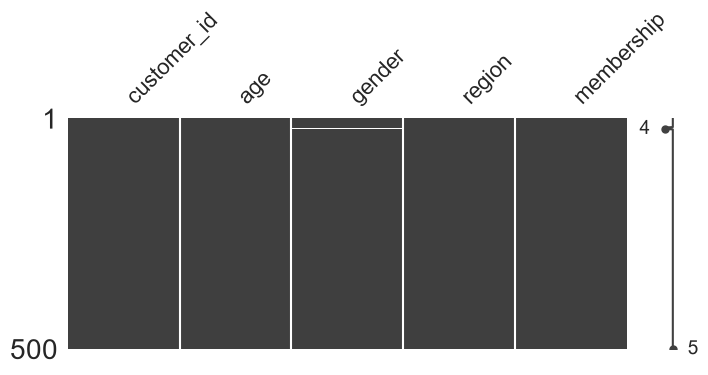

In [12]:
# 스스로 해보자! (2)
# 1) customers에 missingno bar / matrix 그리기
msno.bar(customers, figsize=(8, 3)); plt.show()
msno.matrix(customers, figsize=(8, 3)); plt.show()
# 2) 시기에 따른 결측을 가설로 세우고 (ex: 특정시기 버그발생) 시기로 정렬한 뒤 다시 matrix 그리기
# 3) 극단적으로 결측이 작다면 bar로 충분, 특정 패턴을 볼 수 없을 정도이기 때문

## 전·후 분포 비교 — 검증용 시각화

# 3. 전·후 분포 비교 — 검증용 시각화

Part 2에서 결측의 패턴을 봤습니다. 이제 결측을 *채웠다면*, 채운 결과가 **원래 분포를 망가뜨리지 않았는지** 확인해야 합니다. 평균값으로 대체하면 평균은 그대로 유지되지만 분포가 좁아져 분산이 왜곡됩니다. 시각화로 잡지 못하면 모르고 지나치기 쉬워요.

> ❓ **이 파트에서 답할 질문:** 내가 한 전처리가 데이터의 본질을 **유지**했는가, 아니면 **왜곡**했는가?

## 💡 쉽게 말하면 — 두 분포를 같은 캔버스에 겹친다

```text
[잘 된 처리]   raw 분포        clean 분포
              ▁▃▅▇▅▃▁         ▁▃▅▇▅▃▁     ← 모양이 거의 같음 (위치/폭 보존)

[왜곡된 처리] raw 분포        clean 분포
              ▁▃▅▇▅▃▁          ▆▇▆          ← 중앙으로 뾰족하게 몰림 (분산 왜곡)
```

## 자세히 알아보기 — 검증용 차트 3종

| 차트 | 무엇을 검증하는가 | 코드 |
| --- | --- | --- |
| 히스토그램 겹쳐 그리기 | 분포의 *모양*이 비슷한가 | `sns.histplot(..., alpha=0.5)` 두 번 |
| KDE 곡선 겹쳐 그리기 | 분포의 *추세*가 비슷한가 | `sns.kdeplot(..., fill=True)` |
| Boxplot side-by-side | 중앙·사분위·이상치가 비슷한가 | `sns.boxplot(data=long_df, x=..., y=...)` |

> 💡 **개념 연결:** D+002에서 봤던 히스토그램·박스플롯이, 여기선 *두 상태를 비교*하는 도구가 됩니다. 같은 차트도 *목적*에 따라 다르게 쓰입니다 — Part 1의 메시지가 다시 등장합니다.

> **읽는 법:** 두 막대가 거의 겹치면 처리가 본질을 유지한 것. 한쪽이 아주 다르면 처리가 분포를 바꿨다는 뜻입니다. `stat="density"`로 표기해 두 데이터의 *건수 차이*가 아닌 *모양*을 직접 비교합니다.

> ⚠ **주의:** raw에는 5,000,000원 같은 극단치가 들어 있어 x축이 늘어나 정작 본 분포가 납작해 보일 수 있습니다. 분포 비교에서는 **극단치를 자른 뒤** 다시 그리는 것이 자연스럽습니다 — 다음 셀에서 해봅니다.

> **읽는 법:** KDE(Kernel Density Estimation)는 히스토그램을 부드러운 곡선으로 그린 것입니다. 두 곡선이 거의 일치하면 "정제 후에도 본질이 유지됐다"는 **검증 통과** 신호입니다.

## Tidy long-format로 박스플롯 비교

여러 상태(raw vs clean)를 한 박스플롯에 나란히 그리려면, 데이터를 "긴(long) 포맷"으로 합칩니다. pandas의 `pd.concat`과 새 컬럼 `state`를 활용합니다.

> **읽는 법:** 두 박스의 가운데 선(중앙값)과 상자 폭(IQR)이 비슷하면 본질 유지. clean의 위쪽 이상치 점들이 사라졌다면 우리가 의도한 *상한 클리핑*이 잘 적용된 거예요.

## 범주별 검증 — channel 표기 통일은 됐을까?

수치형뿐 아니라 범주형 정제도 시각화로 검증합니다. `channel`이 `'app'`/`'APP'`/`'app '` 등으로 흩어져 있던 게, 정제 후 깔끔하게 `'app'`/`'web'`으로 통일됐는지 막대로 봅니다.

> **읽는 법:** 왼쪽에 4개 막대(`web`, `app`, `app `, `APP`)가 있었다면, 오른쪽에는 2개(`web`, `app`)만 남아야 합니다. 막대 개수와 합계로 정제 결과를 즉시 검증할 수 있어요.

## 검증이 *실패* 했을 때

분포 비교를 했는데 raw와 clean이 너무 다르다면 어떻게 해야 할까요? "처리가 잘못됐다"가 아니라 "**왜 그렇게 됐는지 다시 생각한다**"가 답입니다. 자주 만나는 시나리오 셋입니다.

| 신호 | 의심할 원인 | 다음 행동 |
| --- | --- | --- |
| clean의 분포가 *뾰족* 하게 좁아짐 | 평균으로 결측 대체 → 분산 축소 | 그룹 평균/중앙값 또는 모델 기반 대체로 교체 |
| clean의 *위쪽 꼬리* 가 잘려나감 | 너무 공격적인 이상치 클리핑 | 분위수 기준 완화 또는 비즈니스 맥락에서 진짜 큰 값 검토 |
| clean의 *봉우리 위치* 가 이동 | 잘못된 변환(스케일/로그) 또는 단위 혼재 | 변환 함수 점검, 단위 통일 |

> 💡 **개념 연결:** 검증 실패는 *문제의 발견*입니다. 차트가 "여기 이상해"라고 말해 주는 거예요. 발견했다는 것 자체가 검증의 가치입니다.

## 데이터로 확인해 봅시다

- **모든 전처리 단계마다 *검증* 시각화를 거치는 습관**이 데이터 품질을 지킵니다. 결측 대체 → 분포 KDE 비교, 이상치 클리핑 → 박스플롯 비교, 표기 통일 → 범주 막대 비교.
- 비교가 곧 분석가의 양심입니다. "잘 됐어요"라는 말 대신 "잘 됐는지 그림으로 확인했습니다"가 더 신뢰를 받습니다.

> 📌 **다른 산업에서는?** 금융 신용평가 모델은 정제 전후 분포가 **법적으로** 같아야 하는 경우가 있습니다(차별 방지). 헬스케어는 결측 대체 전후의 임상 지표 평균이 크게 흔들렸는지 반드시 검증해요.

### 스스로 해보자! ✏️ (3)

> 정답은 하나가 아닙니다. 일단 실행해보세요.

`orders_raw`의 `quantity`(수량)는 100·80 같은 이상치가 있었고, `orders_clean`에서는 IQR 상한으로 클리핑했습니다.

1. **(따라하기)** raw vs clean의 `quantity` 분포를 KDE 또는 히스토그램으로 겹쳐 그려보세요.
2. **(응용)** 박스플롯 side-by-side로도 비교해보세요. (long-format으로 합치는 코드 패턴이 그대로 적용됩니다)
3. **(생각해보기)** 만약 라이프타임이 긴 우량 고객이 진짜로 100개를 주문한 것이라면, 우리가 한 클리핑은 잘한 처리일까요? 시각화에서 *발견*은 했지만 *판단*은 누가 합니까?

<details>
<summary>💡 힌트 (클릭)</summary>

```python
plt.figure(figsize=(9, 4))
sns.kdeplot(orders_raw["quantity"], label="raw", color="#C44E52", fill=True, alpha=0.3)
sns.kdeplot(orders_clean["quantity"], label="clean", color="#4C72B0", fill=True, alpha=0.3)
plt.legend(); plt.title("Quantity — raw vs clean"); plt.show()

# long-format
long_q = pd.concat([
    pd.DataFrame({"quantity": orders_raw["quantity"], "state": "raw"}),
    pd.DataFrame({"quantity": orders_clean["quantity"], "state": "clean"}),
])
sns.boxplot(data=long_q, x="state", y="quantity", order=["raw", "clean"])
plt.title("Quantity — raw vs clean"); plt.show()
```

3번은 정답이 없습니다. **시각화는 발견의 도구, 판단은 비즈니스 맥락의 몫**이라는 게 핵심이에요. 진짜 우량 고객의 대량 주문이라면 클리핑은 손실 추정으로 이어질 수 있습니다.

</details>

### ✅ 짚고 넘어가기

1. 검증용 시각화에서 가장 중요한 성질(비교 가능성)이 왜 그렇게 중요할까요?
2. `stat="density"`로 그리는 이유는 무엇인가요?
3. 박스플롯 side-by-side로 보려면 데이터를 어떤 모양으로 만들어야 하나요?

> 💡 **다음 Part 예고:** 검증을 마쳤다면, 깨끗해진 데이터에서 **새 질문을 만드는** 단계로 갑니다. 다음 Part에서 Seaborn의 다채로운 차트로 **탐색**합니다.

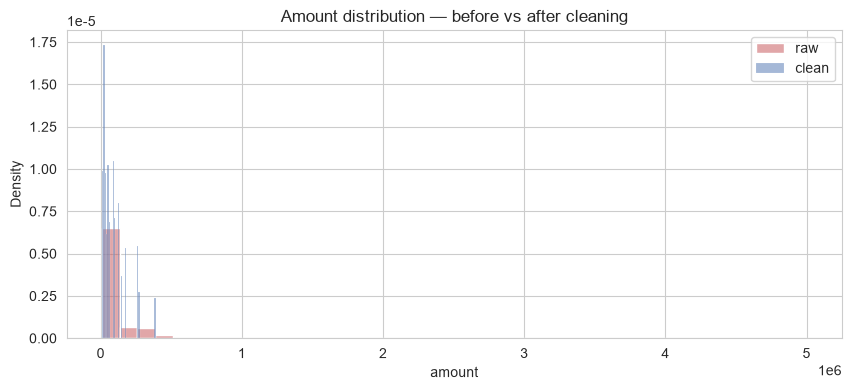

In [13]:
# 1) 히스토그램 겹쳐 그리기 — amount의 정제 전·후
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(orders_raw["amount"].dropna(), bins=40, alpha=0.5,
             label="raw", color="#C44E52", ax=ax, stat="density")
sns.histplot(orders_clean["amount"], bins=40, alpha=0.5,
             label="clean", color="#4C72B0", ax=ax, stat="density")
ax.set_title("Amount distribution — before vs after cleaning")
ax.set_xlabel("amount"); ax.legend()
plt.show()

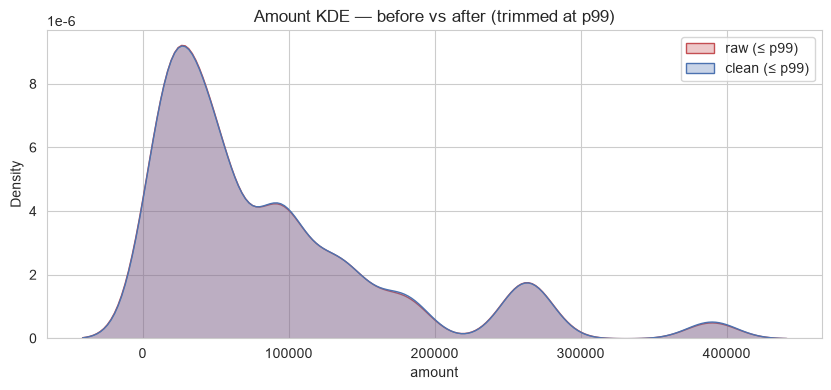

In [14]:
# 2) KDE 겹쳐 그리기 — 극단치 클리핑한 좁은 범위로
upper = orders_clean["amount"].quantile(0.99)
raw_trim = orders_raw["amount"].dropna()
raw_trim = raw_trim[raw_trim <= upper]
clean_trim = orders_clean["amount"][orders_clean["amount"] <= upper]

fig, ax = plt.subplots(figsize=(10, 4))
sns.kdeplot(raw_trim, label="raw (≤ p99)", color="#C44E52", fill=True, alpha=0.3, ax=ax)
sns.kdeplot(clean_trim, label="clean (≤ p99)", color="#4C72B0", fill=True, alpha=0.3, ax=ax)
ax.set_title("Amount KDE — before vs after (trimmed at p99)")
ax.set_xlabel("amount"); ax.legend()
plt.show()

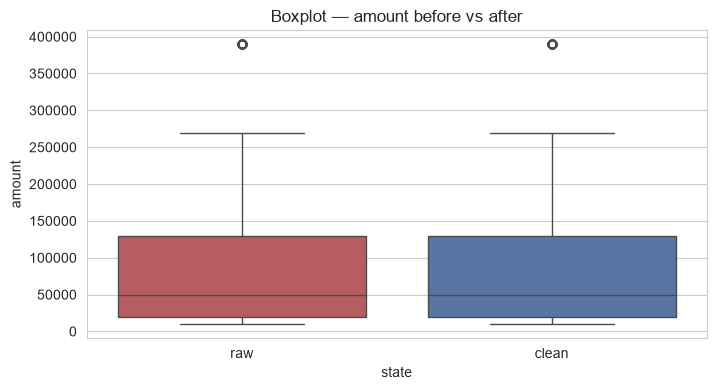

In [15]:
# 3) Boxplot side-by-side — state 컬럼으로 두 상태 합치기
raw_amt = pd.DataFrame({"amount": orders_raw["amount"].dropna(), "state": "raw"})
cln_amt = pd.DataFrame({"amount": orders_clean["amount"], "state": "clean"})
long_amt = pd.concat([raw_amt, cln_amt], ignore_index=True)
long_amt = long_amt[long_amt["amount"] <= upper]   # 시각화를 위해 p99로 클립

plt.figure(figsize=(8, 4))
sns.boxplot(data=long_amt, x="state", y="amount",
            order=["raw", "clean"], palette=["#C44E52", "#4C72B0"])
plt.title("Boxplot — amount before vs after")
plt.show()

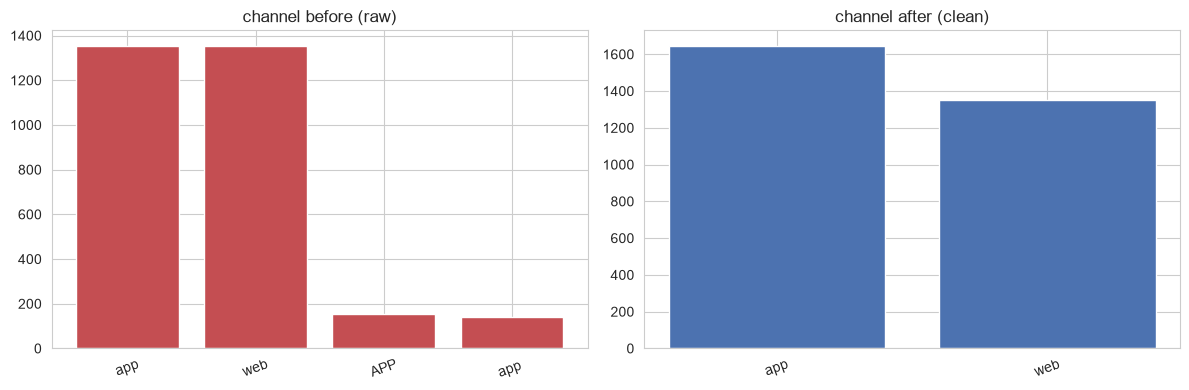

In [16]:
# 4) 범주 정제 검증 — 막대 그래프
raw_ch = orders_raw["channel"].value_counts()
cln_ch = orders_clean["channel"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(raw_ch.index, raw_ch.values, color="#C44E52")
axes[0].set_title("channel before (raw)")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(cln_ch.index, cln_ch.values, color="#4C72B0")
axes[1].set_title("channel after (clean)")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

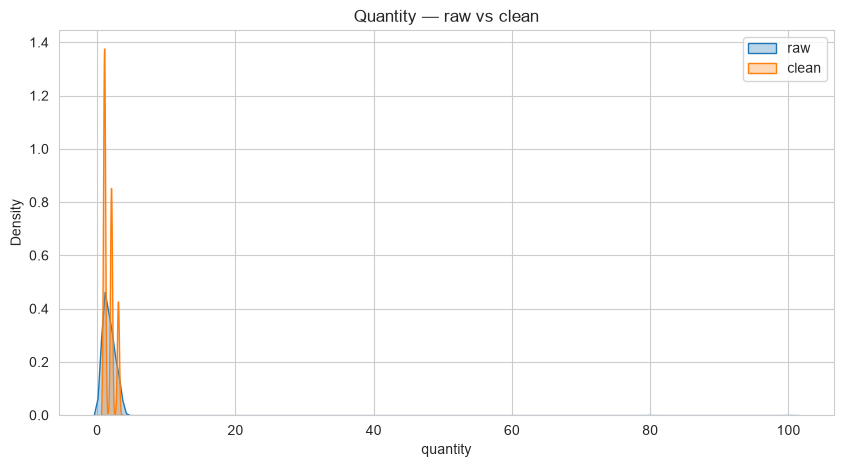

   quantity state
0       1.0   raw
1       1.0   raw
2       2.0   raw
3       3.0   raw
4       1.0   raw


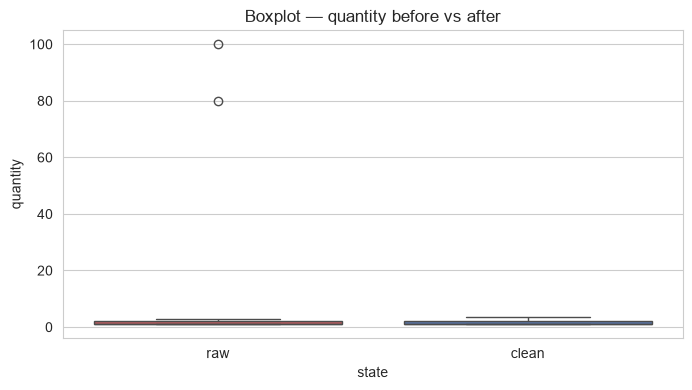

In [17]:
# 스스로 해보자! (3)
# 1) quantity KDE 겹쳐 그리기
sns.kdeplot(orders_raw["quantity"], label="raw", fill=True, alpha=0.3)
sns.kdeplot(orders_clean["quantity"], label="clean", fill=True, alpha=0.3)
plt.legend(); plt.title("Quantity — raw vs clean"); plt.show()

# 2) boxplot side-by-side
raw_quan = pd.DataFrame({"quantity": orders_raw["quantity"].dropna(), "state": "raw"})
cln_quan = pd.DataFrame({"quantity": orders_clean["quantity"], "state": "clean"})
long_quan = pd.concat([raw_quan, cln_quan], ignore_index=True)
long_quan = long_quan[long_quan["quantity"] <= upper]   # 시각화를 위해 p99로 클립

print(long_quan.head())

plt.figure(figsize=(8, 4))
sns.boxplot(data=long_quan, x="state", y="quantity",
            order=["raw", "clean"], palette=["#C44E52", "#4C72B0"])
plt.title("Boxplot — quantity before vs after")
plt.show()

# 3) 정답은 없다, 시각화는 도구, 판단은 비즈니스 맥락의 몫 , 
# 우량고객의 실제 주문 클리핑시 매출하락의 원인이 될 수도

## Seaborn 관계·분포 탐색 — 탐색용 시각화

# 4. Seaborn 관계·분포 탐색 — 탐색용 시각화

검증을 마쳤으니, 이제 정제된 데이터에서 **새로운 질문**을 발굴할 차례입니다. 탐색의 무기는 **다양성과 속도** 예요. 여러 차트를 빠르게 그려가며 의외성을 잡아냅니다.

> ❓ **이 파트에서 답할 질문:** 정제된 데이터에서 다음 분석으로 이어질 만한 **새로운 패턴**을 어떻게 발견할까요?

## 💡 쉽게 말하면 — 탐색은 "보지 않은 각도를 빠르게"

탐색용 차트의 미덕은 *정밀함*이 아니라 *재빠른 시야 확장*입니다. 몇 줄 코드로 한 번에 여러 변수 쌍을 보고, 그중 흥미로운 것을 골라 깊이 파고듭니다.

## 자세히 알아보기 — Seaborn 탐색 도구 카탈로그

| 보고 싶은 것 | Seaborn 함수 | 핵심 인자 |
| --- | --- | --- |
| 단변량 분포 | `histplot`, `kdeplot` | `bins`, `kde`, `fill` |
| 범주별 분포 | `boxplot`, `violinplot` | `x`(범주), `y`(수치) |
| 두 변수 관계 | `scatterplot`, `regplot`, `jointplot` | `hue`로 3번째 변수 추가 |
| 상관 매트릭스 | `heatmap(df.corr())` | `annot=True`, `cmap` |
| 다변량 한눈에 | `pairplot` | `hue`, `vars` |
| 범주별 빈도 | `countplot` | `x`, `hue` |

> 💡 Seaborn의 거의 모든 함수는 `hue=`로 세 번째 변수(보통 범주)를 추가할 수 있습니다. 그것이 탐색의 가장 강력한 한 수예요.

> **읽는 법:** age는 30대 중반에 봉우리가 있는 모양, amount는 낮은 쪽에 몰린 오른쪽 꼬리(right-skew)입니다. 꼬리가 있으면 평균이 중앙값보다 크게 나오므로 "어느 통계량을 보고할지" 선택에 영향을 줍니다.

> 💡 **개념 연결:** 분포의 *모양*이 통계 선택에 영향을 준다는 사실은 다음 모듈(통계)의 핵심 주제와 직결됩니다. 정규분포에 가까우면 평균·표준편차가 유효하고, 오른쪽 꼬리가 있으면 중앙값·IQR을 보고하는 편이 안전합니다. **그림이 통계 선택의 가이드** 인 셈이에요.

> **읽는 법:** countplot은 *범주별 행 개수*를 막대로 그립니다. `hue=`를 더하면 세 번째 범주(예: 성별)로 막대를 쪼개 보여줍니다. "여성 고객이 어느 지역에 많은가" 같은 질문에 답하기 좋아요.

> **읽는 법:** 박스는 사분위·중앙값·이상치를 정확히, 바이올린은 *분포의 두께*까지 보여줍니다. VIP의 바이올린이 위로 길게 늘어났다면 "VIP 중 일부가 대량 주문을 한다"는 패턴의 단서가 됩니다 — 새 질문이 떠오르죠.

> **읽는 법:** 산점도에 `hue="gender"`를 더하면 성별 차이가 색으로 분리됩니다. regplot의 빨간 선은 두 변수의 **선형 추세**입니다. 선이 평평하면 관계가 약하고, 기울어져 있으면 추세가 있다는 뜻이에요. (정확한 검정은 회귀분석에서 다룹니다.)

> **읽는 법:** 셀의 색이 빨갛고 진할수록 양의 상관, 파랗고 진할수록 음의 상관, 흰색에 가까우면 무관에 가깝습니다. `price`와 `amount`가 강한 양의 상관(상품 단가가 비싸면 주문 총액도 큼)이 자연스럽게 보이고, 다른 쌍은 약하게 나타날 거예요. 예상과 다른 셀이 있다면 "왜?"가 다음 분석의 출발점입니다.

> 💡 **개념 연결:** 상관관계가 곧 인과관계는 아닙니다. 이 히트맵은 *질문을 만드는* 지도일 뿐, 결론이 아니라는 점을 기억하세요.

> **읽는 법:** pairplot은 변수 쌍을 모두 산점도로 그리고, 대각선에는 단변량 분포를 보여줍니다. `hue`로 범주를 색으로 분리하면 *집단별 분포 차이*가 한 그림에 다 잡힙니다. 흥미로운 칸을 발견하면 그 두 변수만 따로 깊게 그리면 돼요.

> ⚠ **주의:** pairplot은 변수가 많거나 데이터가 크면 매우 느립니다. *샘플링*과 *주요 컬럼 선별*이 거의 항상 필요합니다.

## 데이터로 확인해 봅시다

- 탐색은 **"한 그림 그리고 한 질문 만들기"** 의 반복입니다. 위 그림들에서 새로 생긴 질문을 노트에 적어두는 습관을 들이세요.
- 발견된 질문은 다음 모듈의 통계 검정·회귀분석·인과추론의 출발점이 됩니다.

> 📌 **다른 산업에서는?** 마케팅은 pairplot으로 *세그먼트별 전환 패턴*을 빠르게 스캔하고, 금융은 heatmap으로 *위험 변수 상관*을 점검합니다. 헬스케어는 violinplot으로 *치료군 간 분포 차이*를 보여줍니다. 도구는 같고 도메인만 바뀝니다.

### 스스로 해보자! ✏️ (4)

> 정답은 하나가 아닙니다. 일단 실행해보세요.

1. **(따라하기)** `region`별 평균 `amount`를 박스플롯으로 그려보세요. (`x="region"`)
2. **(응용)** scatterplot에 `hue="membership"`을 더해 멤버십별로 색을 분리해보세요. 어떤 새 질문이 떠오르나요?
3. **(생각해보기)** pairplot을 변수 10개에 한 번에 돌리면 무엇이 문제가 될까요? 어떻게 대처하시겠어요?

<details>
<summary>💡 힌트 (클릭)</summary>

```python
sns.boxplot(data=df, x="region", y="amount", palette="Set3")
plt.title("Amount by region"); plt.show()

sns.scatterplot(data=df.sample(1500, random_state=1),
                x="age", y="amount", hue="membership", alpha=0.5, palette="Set2")
plt.title("Age vs Amount by membership"); plt.show()
```

3번은 **계산 비용 + 시각적 과부하** 둘 다 문제입니다. 변수 10개면 100칸. 대처: 주요 변수만 4~6개로 추리거나, 우선 heatmap으로 상관이 강한 쌍을 골라 pairplot에는 그것만 넣는 식이에요.

</details>

### ✅ 짚고 넘어가기

1. 탐색용 차트가 *정밀함*보다 *재빠른 시야 확장*을 중시하는 이유는 무엇인가요?
2. `hue=`가 탐색에서 강력한 한 수인 이유를 한 문장으로 말할 수 있나요?
3. heatmap에서 빨간 셀과 파란 셀 중 어느 쪽이 **음의 상관** 인가요?

> 💡 **다음 Part 예고:** 탐색에서 흥미로운 발견을 했다면, 이제 **남에게 보여줄** 차례입니다. 다음 Part에서 Plotly로 동료가 *만질 수 있는* 차트를 만듭니다.

In [18]:
# 탐색을 위해 clean 데이터에 customer/product 정보를 합쳐 둡니다.
# (병합 자체는 D+004의 주제. 여기선 결과만 활용합니다.)
df = (orders_clean
      .merge(customers[["customer_id", "age", "gender", "region", "membership"]], on="customer_id", how="left")
      .merge(products[["product_id", "category", "price"]], on="product_id", how="left"))
# 나이 이상치(999, -3)는 분석 전 제거
df = df[df["age"].between(15, 80)].copy()

print("탐색용 df 모양:", df.shape)
df.head(3)

탐색용 df 모양: (2979, 13)


,order_id,customer_id,product_id,quantity,amount,channel,order_date,age,gender,region,membership,category,price
0,O00001,C0149,P018,1.0,49900.0,app,2025-03-08,40,M,경기,basic,식품,49900
1,O00002,C0126,P002,1.0,49900.0,web,2025-03-07,55,F,대구,basic,식품,49900
2,O00003,C0392,P008,2.0,99800.0,web,2025-02-21,39,F,경기,basic,도서,49900


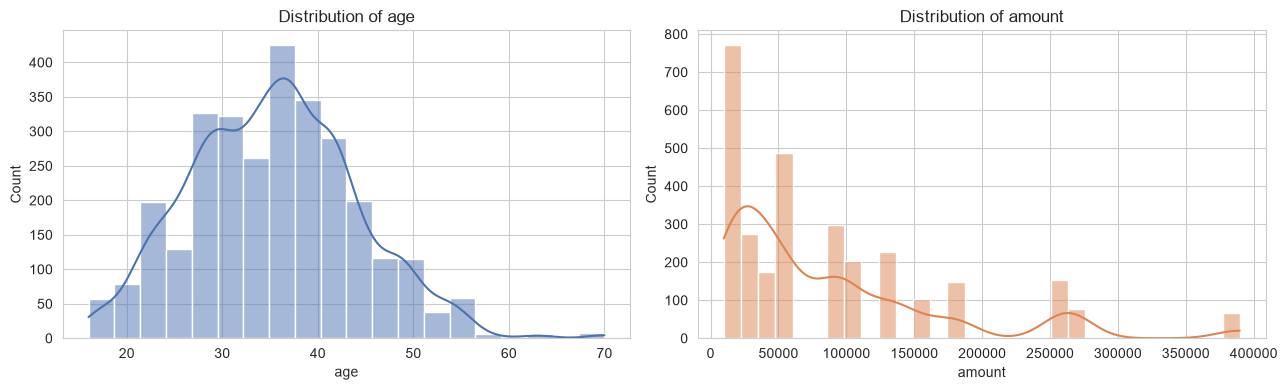

In [19]:
# 1) 단변량 분포 — 히스토그램 + KDE 한 번에
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["age"], bins=20, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of age")
sns.histplot(df["amount"], bins=30, kde=True, ax=axes[1], color="#DD8452")
axes[1].set_title("Distribution of amount")
plt.tight_layout(); plt.show()

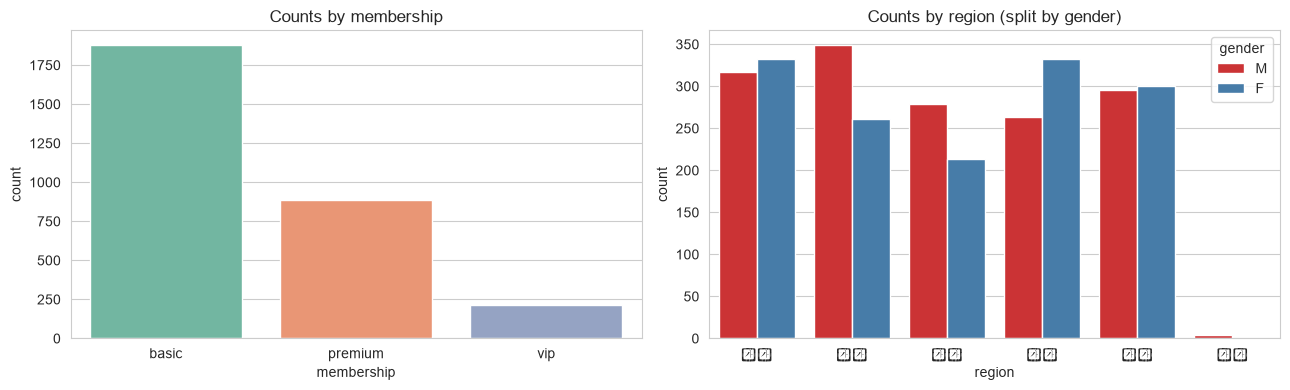

In [20]:
# 범주 빈도 — countplot으로 범주별 개수 한눈에
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x="membership", order=["basic", "premium", "vip"],
              ax=axes[0], palette="Set2")
axes[0].set_title("Counts by membership")

sns.countplot(data=df, x="region", hue="gender", ax=axes[1], palette="Set1")
axes[1].set_title("Counts by region (split by gender)")
plt.tight_layout(); plt.show()

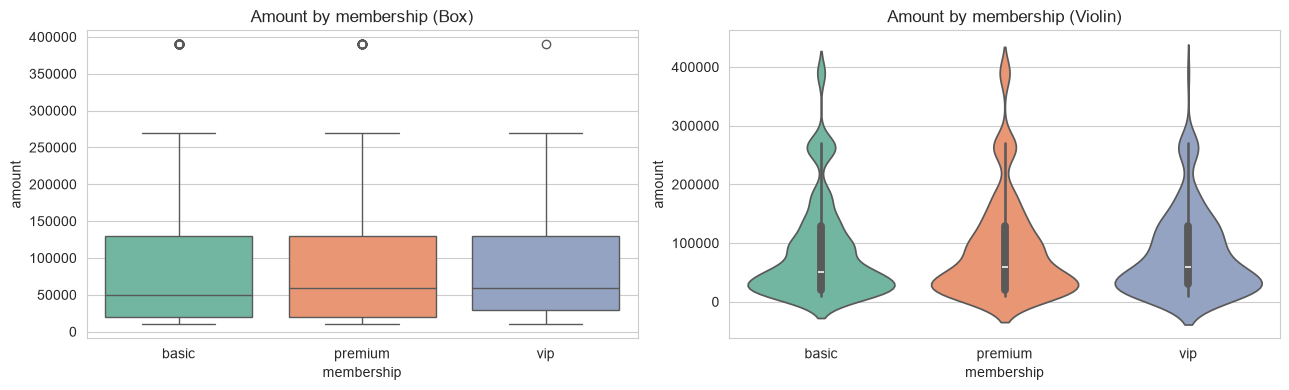

In [21]:
# 2) 범주별 분포 — 박스플롯 + 바이올린플롯 비교
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x="membership", y="amount", order=["basic", "premium", "vip"],
            ax=axes[0], palette="Set2")
axes[0].set_title("Amount by membership (Box)")
sns.violinplot(data=df, x="membership", y="amount", order=["basic", "premium", "vip"],
               ax=axes[1], palette="Set2")
axes[1].set_title("Amount by membership (Violin)")
plt.tight_layout(); plt.show()

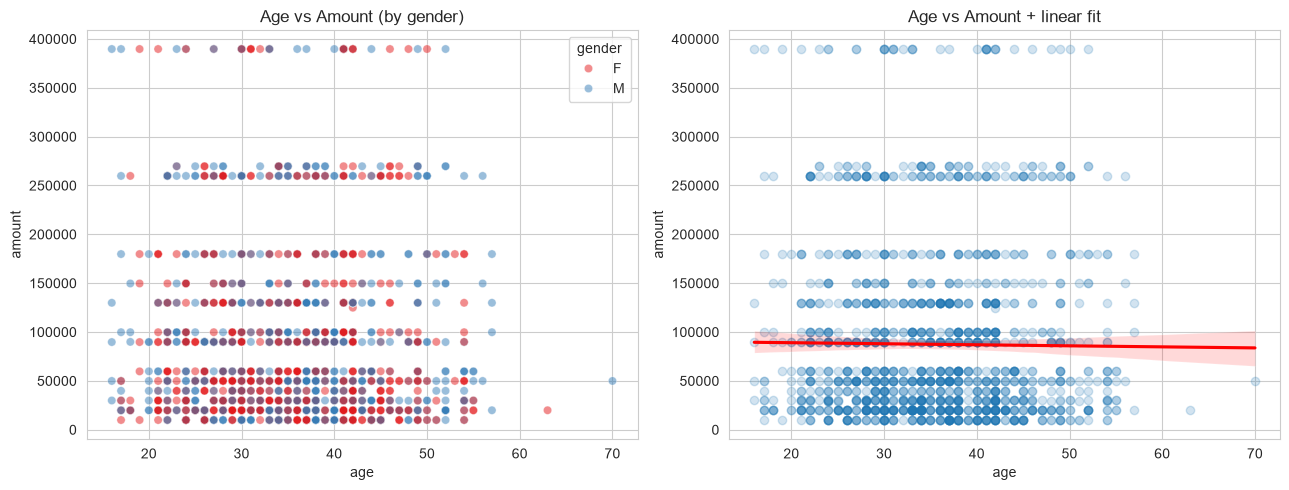

In [22]:
# 3) 두 변수 관계 — scatter + regplot (회귀선 포함)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sample = df.sample(1500, random_state=42)
sns.scatterplot(data=sample, x="age", y="amount", hue="gender",
                alpha=0.5, ax=axes[0], palette="Set1")
axes[0].set_title("Age vs Amount (by gender)")

sns.regplot(data=sample, x="age", y="amount", scatter_kws={"alpha": 0.2},
            line_kws={"color": "red"}, ax=axes[1])
axes[1].set_title("Age vs Amount + linear fit")
plt.tight_layout(); plt.show()

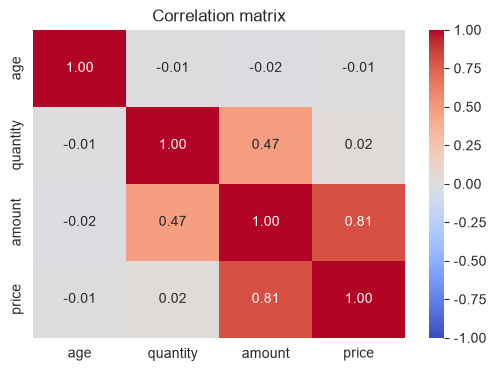

In [23]:
# 4) 상관 매트릭스 히트맵 — 한눈에 변수 쌍의 상관성
num_cols = ["age", "quantity", "amount", "price"]
corr = df[num_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation matrix")
plt.show()

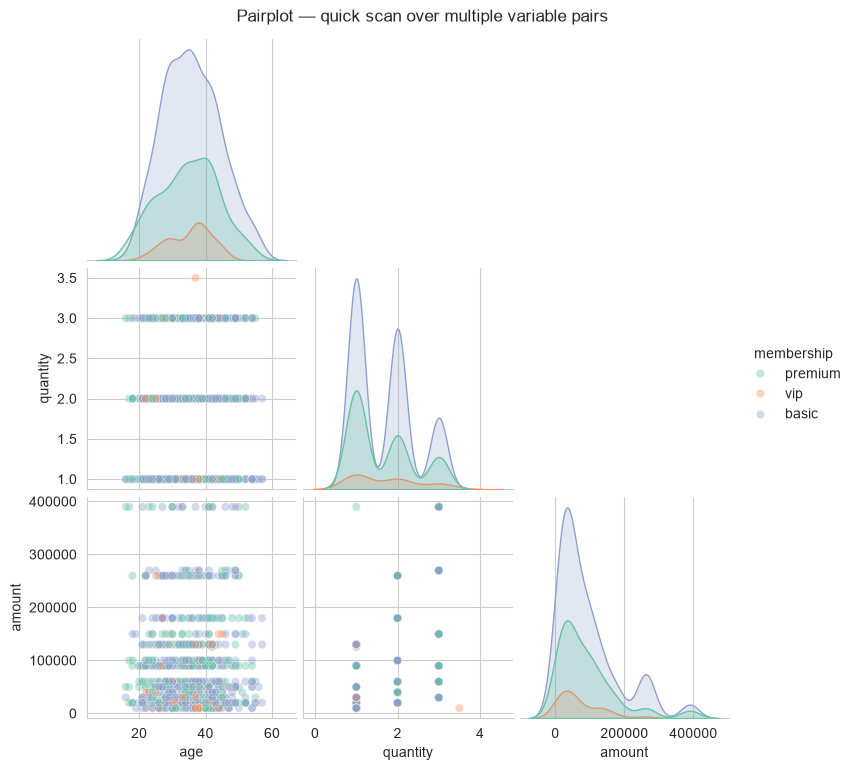

In [24]:
# 5) 다변량 한눈에 — pairplot (탐색의 '한 줄 마법')
sub = df.sample(800, random_state=42)[["age", "quantity", "amount", "membership"]]
sns.pairplot(sub, hue="membership", corner=True, plot_kws={"alpha": 0.4},
             palette="Set2", height=2.5)
plt.suptitle("Pairplot — quick scan over multiple variable pairs", y=1.02)
plt.show()

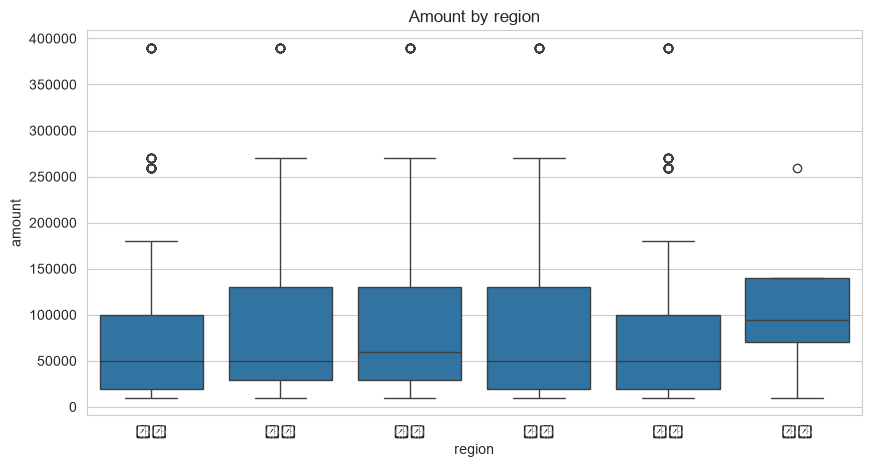

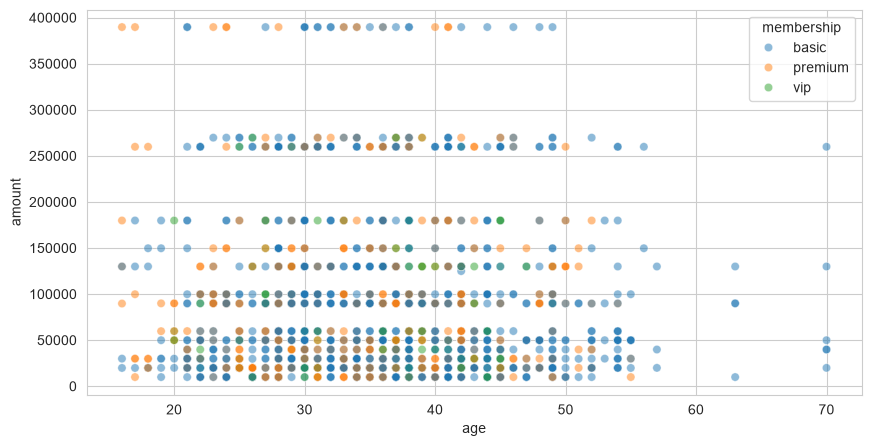

In [25]:
# 스스로 해보자! (4)
# 1) region별 amount 박스플롯
sns.boxplot(data=df, x="region", y="amount"); plt.title("Amount by region"); plt.show()

# 2) age vs amount, hue=membership
sns.scatterplot(data=df.sample(1500, random_state=1),
                x="age", y="amount", hue="membership", alpha=0.5); plt.show()

# 유독 amount가 차이가 나는 지역이 있는가? 그렇다면 왜? / 등급과 amount 사이에는 상관관계가 있는가? 특정연령대나 지역에 vip등급이 치우쳐있지는 않은가?

## Plotly 인터랙티브 전달 — 동료가 만지게 하는 차트

# 5. Plotly 인터랙티브 전달 — 동료가 만지게 하는 차트

탐색에서 발견한 인사이트를 동료/임원에게 보고할 때, 정적 차트는 "그래서 이 값이 뭐야?"라는 질문을 자주 받습니다. **인터랙티브 차트는 그 질문에 차트 스스로 답하게** 합니다 — 마우스 호버, 줌, 필터.

> ❓ **이 파트에서 답할 질문:** 보는 사람이 직접 들여다볼 수 있는 차트는 어떻게 만들고, 정적 차트와 무엇이 다를까요?

## 💡 쉽게 말하면 — 정적 vs 인터랙티브

```text
[정적 차트]                     [인터랙티브 차트 (Plotly)]
PNG·SVG · 한 장면 한 메시지       호버로 정확한 값 / 줌·팬 / 필터로 일부만
인쇄·PDF에 강함                   웹 대시보드·노트북·발표에 강함
빠르게 많이 그릴 때 좋음          한 차트로 여러 질문을 다룰 때 좋음
```

> 💡 **선택 기준:** 한 메시지를 *고정*해 전달할 거면 정적이 더 깔끔합니다. 청중이 직접 *탐색하면서 이해*하길 원하면 인터랙티브가 강력해요.

## 자세히 알아보기 — Plotly Express 핵심 함수

| 함수 | 용도 |
| --- | --- |
| `px.scatter(df, x, y, color, size, hover_data)` | 관계 (호버에 추가 정보) |
| `px.line(df, x, y, color)` | 추이 (시간 시리즈) |
| `px.bar(df, x, y, color, barmode)` | 비교 |
| `px.histogram(df, x, color, barmode)` | 분포 (그룹별 겹쳐 보기) |
| `px.box(df, x, y, color)` | 분포 비교 (호버에 사분위 값) |

> **읽는 법:** 점 위에 마우스를 올려보세요. 그 주문의 `customer_id`·`region`·`category`까지 호버로 나타납니다. 범례의 멤버십 항목을 클릭하면 해당 그룹이 숨겨지거나 표시됩니다. 보고를 받는 사람이 *자기 질문*에 따라 차트를 직접 조작할 수 있어요.

> **읽는 법:** 시간 추이는 인터랙티브의 가치가 가장 큽니다. 한 부분만 확대해서 보기, 특정 기간으로 *범위 슬라이드*, 호버로 정확한 일자·금액 확인 — 정적 PNG로는 어려운 것들이에요.

> **읽는 법:** 카테고리 × 멤버십 두 차원의 비교가 한 그림에 들어갑니다. 범례에서 한 멤버십만 켜면 *그 그룹의 카테고리 분포*만 보여요. 같은 데이터를 정적 막대로 그리면 그래프를 여러 장 만들거나 색을 더 빽빽이 쓰게 됩니다.

## 정적 vs 인터랙티브, 언제 무엇을?

| 상황 | 추천 |
| --- | --- |
| 인쇄·논문·PDF 보고서 | 정적 (matplotlib/Seaborn) |
| 노트북 안에서 동료가 탐색 | 인터랙티브 (Plotly) |
| 임원 발표용 슬라이드 한 장 | 정적 + 큰 글씨·한 메시지 |
| 사내 대시보드 | 인터랙티브 (Plotly Dash/Streamlit) |

## 데이터로 확인해 봅시다

- **노트북 보고**(분석 결과를 노트북째 동료에게 공유): Plotly가 강력합니다. 보는 사람이 직접 호버·줌으로 의문을 해결합니다.
- **임원 발표**: 정적 + 큰 글자 + "한 차트 한 메시지" 가 더 안전합니다. 발표 중 차트를 만지면 흐름이 끊겨요.

> 📌 **다른 산업에서는?** 사내 BI(비즈니스 인텔리전스) 대시보드는 거의 다 인터랙티브입니다. 금융 리포트는 규제 때문에 정적 PDF가 표준이고요. 도구 선택의 절반은 **청중과 매체**가 결정합니다.

> 💡 **더 알고 싶다면:** Plotly 차트는 `fig.write_html("out.html")`로 저장하면 노트북 없이도 브라우저에서 열어 볼 수 있고, 슬랙·이메일로 첨부도 가능합니다. `fig.write_image("out.png")`(`kaleido` 필요)로 정적 이미지를 뽑아 PDF 보고서에 넣을 수도 있어요.

### 스스로 해보자! ✏️ (5)

> 정답은 하나가 아닙니다. 일단 실행해보세요.

1. **(따라하기)** `px.histogram`으로 `amount`의 분포를 그리되 `color="membership"`을 더해 멤버십별로 색을 분리해보세요.
2. **(응용)** `barmode="overlay"`와 `barmode="stack"`을 바꿔보며 표시 모드 차이를 비교해보세요.
3. **(생각해보기)** 같은 차트를 임원 보고용으로 *정적*으로 다듬는다면, 무엇을 더하고 무엇을 빼야 할까요?

<details>
<summary>💡 힌트 (클릭)</summary>

```python
fig = px.histogram(df, x="amount", color="membership",
                   barmode="overlay", opacity=0.5,
                   title="Amount distribution by membership")
fig.update_layout(width=900, height=400); fig.show()
```

3번 — 임원 보고용으로는 (a) 한 메시지만 강조(예: VIP 평균이 X배), (b) 라벨 글자 크게, (c) 색 단순화, (d) 인터랙션 제거. 더하는 것보다 *빼는* 것이 더 중요합니다.

</details>

### ✅ 짚고 넘어가기

1. 정적 차트와 인터랙티브 차트는 각각 어떤 상황에서 더 강한가요?
2. Plotly의 `hover_data=`로 무엇을 더 보여줄 수 있나요?
3. 임원 발표에서 인터랙티브 차트를 쓰지 *않는* 것이 더 좋을 수 있는 이유는 무엇일까요?

> 💡 **다음 단계 예고:** 이제 셋(검증·탐색·전달)을 모두 익혔으니, 한 데이터셋을 끝까지 끌고 가며 통합해봅시다.

# 🧪 종합 실습 — 한 데이터셋으로 끝까지 끌고 가기

이번 실습은 **세 시나리오 + 마무리**으로 구성됩니다. 모두마켓의 **웹 접속 로그** 데이터를 받아 정제 → 검증 → 탐색 → 전달 → 인사이트 보고까지 진행합니다. 같은 모두마켓이지만 *서비스 운영 관점*의 데이터를 다루는 시간이에요.

> 💡 이번 데이터는 **모두마켓의 웹 접속 로그**입니다. 주문(orders)·고객(customers) 외에 또 다른 핵심 데이터셋이 바로 **사용자 행동 로그**(web_logs)예요. 응답 시간·디바이스·요청 경로 같은 *시스템* 변수를 다룹니다. 같은 도메인 안에서도 *어떤 관점의 데이터*인가에 따라 분석 질문이 달라진다는 점을 느껴보세요.

## 시나리오 1 — 결측 패턴 진단 (missingno)

먼저 결측의 *모양*을 봅니다. `logs_raw`의 어디에 결측이 몰려 있는지, 두 컬럼이 같이 비는지를 missingno 3종으로 진단하세요.

질문:
- `response_time_ms`의 결측 비율은 얼마인가요?
- matrix를 보면 결측이 무작위로 흩어져 있나요, 한쪽에 몰려 있나요?
- 시간(`hour`)순으로 정렬해 다시 그렸을 때 패턴이 달라지나요?

> **읽는 법:** `hour` 정렬 matrix에서 *위쪽*에 결측이 몰려 있다면, 그건 **새벽 시간대(hour=2~4) 로그에 결측이 집중**됨을 의미합니다. "심야 시간대 응답 측정 모듈 점검 작업으로 측정값 누락" 같은 가설을 세울 수 있어요. 단순 개수만 봐서는 절대 알 수 없는 사실입니다.

## 시나리오 2 — 정제 + 검증 (전·후 분포 비교)

시나리오 1의 진단 결과를 바탕으로 정제를 한 뒤, 정제 전·후의 분포를 시각적으로 검증합니다. 이번엔 다음 처리를 적용합니다.

1. 중복 제거
2. `device` 표기 통일 (대소문자 혼재)
3. `hour` 이상치(99) 제거
4. `response_time_ms` 결측은 `request_path`(요청 경로)별 *중앙값*으로 대체
5. `response_time_ms` 극단치는 99% 분위수로 클리핑

> **읽는 법:** 왼쪽·가운데가 비슷한 모양이면 분포 본질이 유지됐다는 검증 통과. 오른쪽 막대로 device의 고윳값이 5 → 2로 줄어든 게 확인되면 표기 통일이 잘 적용됐다는 뜻이에요.

## 시나리오 3 — 정제 데이터에서 패턴 탐색

검증을 마친 `logs_clean`을 가지고, 이제 **새 질문**을 발굴합니다. 에러 응답(`is_error`)의 시간대 패턴, 요청 경로별 응답 시간 분포 등을 탐색해보세요.

> **읽는 법:** 왼쪽에서 정상 로그는 낮 시간에 봉우리가 있고, 만약 에러 로그(빨강)가 새벽에 *상대적으로* 많아 보인다면 "심야 시간대 에러 패턴" 가설이 됩니다. 오른쪽 박스플롯에서 요청 경로별 응답 시간 분포의 차이가 보이면 그것 자체가 새 질문이고요(예: `/checkout`이 다른 페이지보다 느리다 → 결제 단계 최적화 후보).

## 시나리오 4 — 인사이트를 전달용 인터랙티브 차트로

탐색에서 발견한 패턴을 동료에게 보고할 한 장의 인터랙티브 차트로 다듬어 봅시다.

## 📊 EDA & 시각화 보고서 작성 (제출물)

지금까지의 진단·검증·탐색·전달 결과를 아래 **보고서 양식**에 맞춰 마크다운으로 정리하세요. 이것이 오늘의 최종 산출물입니다.

```markdown
# 모두마켓 웹 접속 로그 — EDA & 시각화 보고서

## 1. 데이터 개요
- 행/열: (___행, ___열)
- 주요 컬럼: log_id, session_id, response_time_ms, request_path, device, hour, is_error

## 2. 결측 진단 (missingno)
- `response_time_ms` 결측 비율: ___ %
- 결측 패턴: (어디에 몰려 있나 — hour 기준 / 시간 정렬 후 관찰)
- 의심 가설: (예: 심야 시간대 측정 모듈 점검으로 측정값 누락 등)

## 3. 정제와 검증 (전·후 분포 비교)
- 적용한 정제: 중복 제거 / device 표기 통일 / hour 이상치 / response_time_ms 결측 대체 / 극단치 클리핑
- KDE 비교 결과: (본질이 유지됨 / 한쪽이 좁아짐 등)
- device distinct: 5 → ___ (정상)

## 4. 탐색에서 도출한 새 질문
- (예) "새벽 시간대 에러 응답 비중이 낮보다 높은가?"
- (예) "`/checkout` 응답 시간이 다른 경로보다 길다 — 결제 단계 최적화 후보인가?"
- (정답 없음 — 본인이 본 패턴을 글로 적기)

## 5. 전달용 차트 1개 (이미지 또는 코드 인용)
- 차트 한 장 + "한 줄 메시지"

## 6. 다음 분석 제안
- (예) 에러 응답 원인 추적 / 시간대 세분화 분석 / 디바이스별 성능 비교
```

> 💡 빈칸을 채울 때, 각 항목 뒤에 **"왜 그렇게 판단했는지"** 한 줄 근거를 적으면 훌륭한 보고서가 됩니다. 시각화의 목적이 결국 "근거 있는 판단"이라는 것을 잊지 마세요.

# ✅ 오늘의 퀴즈

배운 내용을 잠깐 확인해볼게요. 틀려도 괜찮습니다. "이런 걸 배웠지" 하고 떠올리는 용도예요.

### 개념 퀴즈

1. 같은 산점도라도 다르게 그리게 만드는 세 가지 *목적*은 무엇인가요?
2. `missingno`의 `matrix`와 `heatmap`은 각각 무엇을 보여주나요?
3. 전·후 분포를 한 캔버스에 그릴 때 `stat="density"`를 쓰는 이유는?
4. Seaborn에서 세 번째 변수(범주)를 색으로 더하는 인자는 무엇인가요?
5. 정적 차트와 인터랙티브 차트를 고를 때 가장 먼저 묻는 질문은 무엇이라고 생각하나요?

### 코드 퀴즈

`orders_clean`에서 `category`별 평균 `amount`를 인터랙티브 막대 그래프로 그리세요. 색은 멤버십으로 나누고(`color="membership"`), 그룹 모드(`barmode="group"`)를 사용하세요.

> **읽는 법:** 같은 카테고리 안에서도 VIP의 막대가 다른 멤버십보다 높다면 "VIP의 카테고리별 객단가가 높다"는 보고 메시지가 됩니다. 인터랙티브이므로 보는 동료가 범례에서 한 멤버십만 따로 켜고 끄며 확인할 수 있어요.

# 🎓 정리 & 다음 시간 예고

## 오늘 배운 것이 어떻게 이어졌나

```text
[Part 1] 차트 3목적                목적이 차트를 결정한다
   ↓  (검증의 첫 도구가 결측 시각화)
[Part 2] missingno                결측의 '모양'을 본다
   ↓  (모양을 봤으니 채우고 검증한다)
[Part 3] 전·후 분포 비교 (검증)    정제 결과 분포 변형 여부 확인
   ↓  (검증 통과 → 깨끗한 데이터로 탐색)
[Part 4] Seaborn 탐색             새 질문을 만드는 그림
   ↓  (탐색 결과를 동료에게 전달)
[Part 5] Plotly 인터랙티브 전달   보는 사람이 만지게 한다
   ↓
[종합 실습] 모두마켓 웹 접속 로그로 전 과정 통합 → EDA 보고서
```

## 한 장 정리표

| 주제 | 핵심 한 줄 | 대표 코드 |
| --- | --- | --- |
| 차트 3목적 | 차트 전에 *왜*를 먼저 정한다 | (생각의 단계) |
| 결측 시각화 | 개수가 아닌 *모양*을 본다 | `msno.bar / matrix / heatmap` |
| 전·후 비교 | 분포 본질이 유지됐는지 검증 | `sns.kdeplot(raw); sns.kdeplot(clean)` |
| 탐색 | hue=로 세 번째 변수까지 한 그림에 | `sns.scatterplot(x,y,hue=)` |
| 다변량 한눈에 | pairplot 한 줄로 시야 확장 | `sns.pairplot(df, hue=)` |
| 인터랙티브 | 보는 사람이 직접 들여다본다 | `px.scatter / line / bar` |

## 진단/탐색 결과 → 다음 분석 도구

오늘 탐색에서 얻은 신호는 자연스럽게 다음 학습으로 이어집니다.

| 오늘 발견한 신호 | 자연스러운 다음 분석 |
| --- | --- |
| "결측이 시간대에 몰려 있다" | 결측 처리·시간 분석 — D+003·D+005 기법 결합 (마무리에서) |
| "두 변수의 관계가 강해 보인다" | 상관·회귀 분석 — 다음 모듈 |
| "집단별 평균이 달라 보인다" | t-검정·ANOVA — 다음 모듈 |
| "여러 변수가 동시에 영향을 준다" | 다중 회귀 / PCA — 다음 모듈 |
| "전체 파이프라인을 한 코드로 묶고 싶다" | D+009 종합 프로젝트 — 인제스트→정제→저장 자동화 |

## 🎓 다음 시간 예고

> **"지금까지의 모든 기법을 한 파이프라인으로 통합한다."**
>
> 다음 시간(D+009)은 모듈의 **마무리** 입니다. D+003~D+008에서 배운 결측·이상치·병합·문자열·날짜·자동화·시각화 기법을 *모두* 한 노트북에 모아 "인제스트 → 품질 진단 → 정제 → 변환 → Parquet 저장 → 품질 리포트" 파이프라인을 만듭니다. 그리고 그 결과를 GitHub 포트폴리오에 올려 모듈을 마무리합니다. 오늘 만든 시각화 보고서가 마무리 보고서의 토대가 될 거예요.

# 📝 오늘의 과제

오늘 만든 **EDA & 시각화 보고서**를 다듬어 GitHub에 제출합니다.

## 제출물

1. 종합 실습의 모두마켓 웹 접속 로그를 시각화로 끝까지 풀어낸 노트북(`.ipynb`)
2. 마무리 양식을 채운 **EDA & 시각화 보고서**(노트북 안 마크다운 셀로 작성)

## 필수 과제

- [ ] `missingno` 3종(bar/matrix/heatmap)을 모두 사용해 결측 패턴을 진단했다.
- [ ] 정제 전·후 분포를 **두 종류 이상**의 차트로 비교 검증했다.
- [ ] Seaborn으로 *탐색* 차트 두 개 이상을 그리고, 각각에서 한 가지씩 **새 질문**을 도출했다.
- [ ] 발견한 인사이트 중 하나를 *전달용* Plotly 인터랙티브 차트로 다듬었다.
- [ ] 마무리 보고서 양식(6개 항목)을 모두 채웠다.

## 심화 과제 (선택)

- [ ] `fig.write_html("report_chart.html")`로 인터랙티브 차트를 저장하고, GitHub에 함께 올렸다.
- [ ] `is_error` 비율이 가장 높은 시간대를 식별하고, 그 근거(차트 + 한 문장 해석)를 적었다.
- [ ] missingno의 `matrix`를 정렬 전/후로 비교해서 "어떻게 정렬하면 패턴이 더 잘 보이는지"의 사례를 추가했다.

## 제출 방법 (GitHub)

이번 주는 본격 PR 흐름을 적용합니다.

```bash
# 1) 작업 브랜치 만들기
git checkout -b feature/d008-visualization

# 2) 노트북 추가 & 커밋
mkdir -p D008
mv D008_*.ipynb D008/
git add D008/
git commit -m "D008 시각화로 검증·탐색·전달 보고서 제출"

# 3) 푸시하고 main으로 PR 만들기
git push -u origin feature/d008-visualization
# GitHub 웹에서 'Compare & pull request' → 본문에 '오늘 발견한 새 질문' 한 줄 적기
```

## 평가 기준

| 축 | 무엇을 보나 |
| --- | --- |
| 정확성 | 시각화 코드가 오류 없이 돌고, 라벨·범례·축이 정확한가 |
| 합리성 | 차트 *목적*(검증·탐색·전달)에 맞는 도구를 골랐는가 |
| 인사이트 | 탐색에서 도출한 *새 질문*이 분석가의 시선으로 쓰였는가 |

> 💡 모두의연구소의 과제는 순위를 매기지 않습니다. **"어제의 나보다 그림으로 데이터를 더 잘 읽게 되었는가"** 가 기준이에요. PR 본문에 *오늘 발견한 새 질문 한 줄*을 적어 동료와 공유하는 것까지가 과제의 완성입니다.

---

수고하셨습니다! 🎉

오늘 여러분은 시각화의 **세 쓸모(검증·탐색·전달)** 를 한 데이터셋으로 끝까지 따라가 봤습니다. 결측의 *모양*을 보고, 정제의 *결과*를 그림으로 검증하고, 깨끗해진 데이터에서 *새 질문*을 만들고, 발견을 동료가 *만질 수 있는* 차트로 다듬었어요. 이제 데이터에게 묻고, 데이터가 보여주는 답을 다시 사람에게 전하는 한 사이클을 마쳤습니다.

다음 시간(D+009)은 모듈의 마지막, 마무리입니다. 지금까지의 모든 기법을 한 파이프라인으로 통합해, 여러분만의 포트폴리오를 완성하러 갑시다. 천천히, 그러나 멈추지 않고 가봅시다. 🚀

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 교안은 생성형 AI를 활용해 제작하고 제작자가 검수했습니다.<br>
무단 복제 및 배포를 금합니다.</sub>

In [26]:
%pip install ipython -q

Note: you may need to restart the kernel to use updated packages.


In [27]:
import sys
print(sys.executable)

import IPython
print(IPython.__version__)

c:\Users\baram\anaconda3\envs\myenv\python.exe
9.15.0


In [28]:
%pip install nbformat -q

Note: you may need to restart the kernel to use updated packages.


In [29]:
# 1) 인터랙티브 산점도 — hover에 고객 정보까지

sample = df.sample(800, random_state=42)
fig = px.scatter(
    sample, x="age", y="amount",
    color="membership",
    size="quantity", size_max=15,
    hover_data=["customer_id", "region", "category"],
    title="Age vs Amount (interactive) — hover/zoom/filter",
)
fig.update_layout(width=900, height=500)
fig.show()

In [30]:
# 2) 시간 추이 — 일자별 매출 추이 (인터랙티브 line)
daily = (df.assign(day=df["order_date"].dt.date)
           .groupby("day")["amount"].sum().reset_index())
fig = px.line(daily, x="day", y="amount",
              title="Daily total amount (interactive)",
              markers=True)
fig.update_layout(width=900, height=400)
fig.show()

In [31]:
# 3) 비교 — 카테고리·멤버십 교차 막대 (barmode='group')
grouped = (df.groupby(["category", "membership"])["amount"].sum().reset_index())

fig = px.bar(grouped, x="category", y="amount", color="membership",
             barmode="group",
             category_orders={"membership": ["basic", "premium", "vip"]},
             title="Total amount by category × membership (interactive)")
fig.update_layout(width=900, height=450)
fig.show()

In [ ]:
# 스스로 해보자! (5)
fig = px.histogram(df, x="amount", color="membership",
                    barmode="overlay", opacity=0.5,
                    title="Amount distribution by membership")
fig.update_layout(width=900, height=400); fig.show()

#등급별 amount 정확하게 보는 데에 유리

In [ ]:
fig = px.histogram(df, x="amount", color="membership",
                    barmode="stack", opacity=0.5,
                    title="Amount distribution by membership")
fig.update_layout(width=900, height=400); fig.show()

#값의 전체 합계를 보기에 유리

In [33]:
# ─────────────────────────────────────────────
# 모두마켓 웹 접속 로그(가상) — 일부러 오염을 심어 둡니다.
# ─────────────────────────────────────────────
np.random.seed(7)
n_log = 2500
logs_raw = pd.DataFrame({
    "log_id":           [f"L{str(i).zfill(6)}" for i in range(1, n_log + 1)],
    "session_id":       np.random.choice([f"S{str(i).zfill(4)}" for i in range(1, 401)], n_log),
    "response_time_ms": np.abs(np.random.normal(180, 80, n_log)).round(0),
    "request_path":     np.random.choice(["/home", "/category", "/product", "/cart", "/checkout"], n_log,
                                         p=[0.35, 0.2, 0.25, 0.1, 0.1]),
    "device":           np.random.choice(["mobile", "Mobile", "MOBILE", "desktop", "DESKTOP"], n_log,
                                         p=[0.35, 0.15, 0.2, 0.2, 0.1]),
    "hour":             np.random.randint(0, 24, n_log),
    "is_error":         np.random.choice([0, 1], n_log, p=[0.97, 0.03]),
})
# 의도적 오염
# (a) response_time_ms 결측 (심야 시간대에 많이 — 측정 모듈 점검 시간) — MAR 패턴
night = logs_raw["hour"].isin([2, 3, 4])
night_idx = logs_raw[night].sample(min(80, night.sum()), random_state=1).index
day_idx = logs_raw[~night].sample(40, random_state=1).index
logs_raw.loc[night_idx, "response_time_ms"] = np.nan
logs_raw.loc[day_idx, "response_time_ms"] = np.nan
# (b) response_time_ms 이상치 (네트워크 정체로 60초·45초 지연된 응답)
logs_raw.loc[5, "response_time_ms"] = 60_000
logs_raw.loc[6, "response_time_ms"] = 45_000
# (c) hour 이상치 (잘못된 값)
logs_raw.loc[100, "hour"] = 99
# (d) 중복
logs_raw = pd.concat([logs_raw, logs_raw.iloc[[0, 1]]], ignore_index=True)

print("웹 로그 준비:", logs_raw.shape, "| 결측 response_time_ms:", logs_raw["response_time_ms"].isna().sum())
logs_raw.head(3)

웹 로그 준비: (2502, 7) | 결측 response_time_ms: 120


,log_id,session_id,response_time_ms,request_path,device,hour,is_error
0,L000001,S0176,275.0,/home,Mobile,23,0
1,L000002,S0197,217.0,/category,mobile,8,0
2,L000003,S0026,85.0,/home,desktop,6,0


log_id                0
session_id            0
response_time_ms    120
request_path          0
device                0
hour                  0
is_error              0
dtype: int64
log_id              0.0
session_id          0.0
response_time_ms    4.8
request_path        0.0
device              0.0
hour                0.0
is_error            0.0
dtype: float64


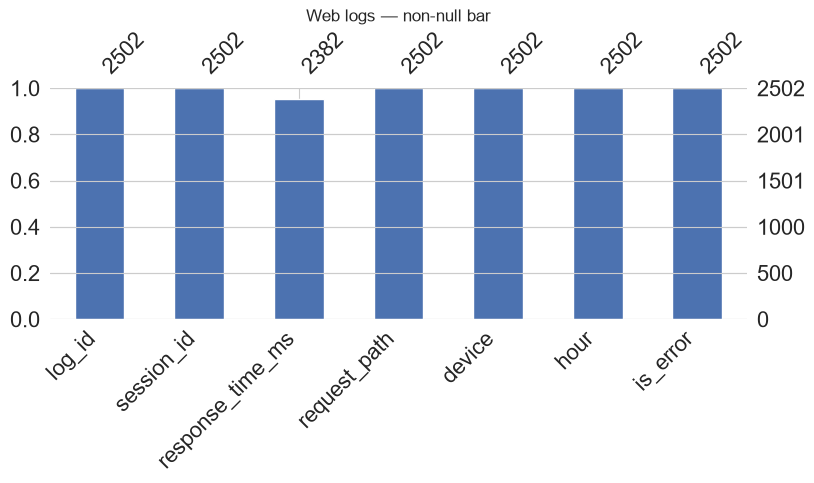

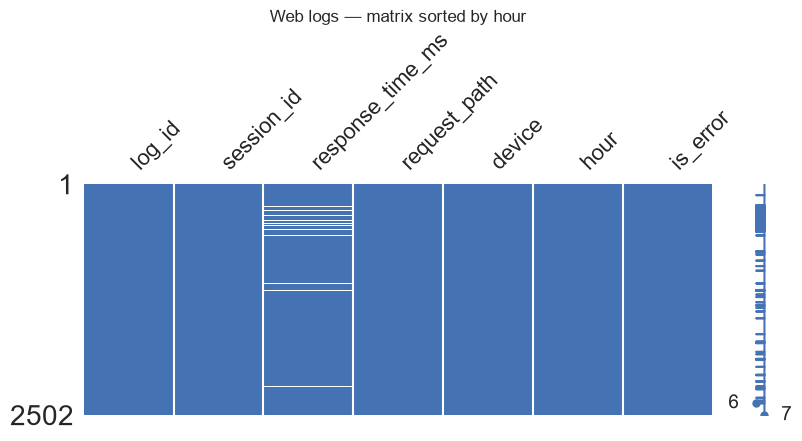

In [34]:
# 시나리오 1 — 결측 진단
print(logs_raw.isnull().sum())
print((logs_raw.isnull().mean() * 100).round(1))

msno.bar(logs_raw, color="#4C72B0", figsize=(9, 3))
plt.title("Web logs — non-null bar"); plt.show()

msno.matrix(logs_raw.sort_values("hour"), color=(0.27, 0.45, 0.70), figsize=(9, 3))
plt.title("Web logs — matrix sorted by hour"); plt.show()

In [35]:
# 시나리오 2 — 정제
logs_clean = logs_raw.drop_duplicates(subset="log_id").reset_index(drop=True)
# device 표기 통일 (대소문자 혼재)
device_map = {"mobile": "mobile", "Mobile": "mobile", "MOBILE": "mobile",
              "desktop": "desktop", "DESKTOP": "desktop"}
logs_clean["device"] = logs_clean["device"].map(device_map)
# hour 이상치 제거 (사실 0~23 외는 모두 이상)
logs_clean = logs_clean[logs_clean["hour"].between(0, 23)].copy()
# response_time_ms 결측 — 요청 경로별 중앙값으로 대체
medians = logs_clean.groupby("request_path")["response_time_ms"].median()
need = logs_clean["response_time_ms"].isna()
logs_clean.loc[need, "response_time_ms"] = logs_clean.loc[need, "request_path"].map(medians)
# response_time_ms 클리핑 (p99)
cap = logs_clean["response_time_ms"].quantile(0.99)
logs_clean.loc[logs_clean["response_time_ms"] > cap, "response_time_ms"] = cap

print("clean 모양:", logs_clean.shape, "| 결측 response_time_ms:", logs_clean["response_time_ms"].isna().sum())

clean 모양: (2499, 7) | 결측 response_time_ms: 0


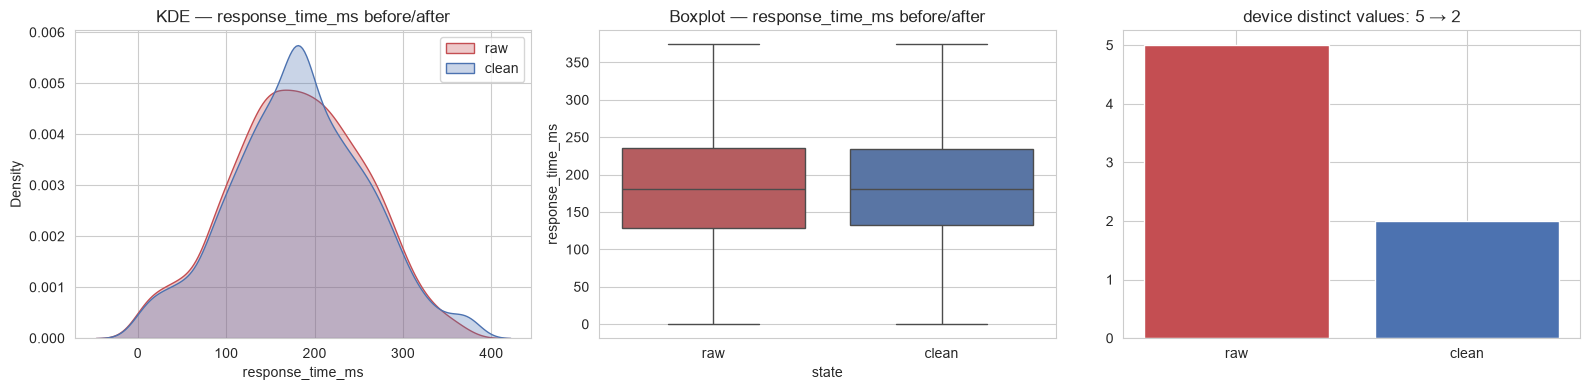

In [36]:
# 검증 — 전후 분포 비교 (3종 세트)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) KDE 겹쳐
raw_rt = logs_raw["response_time_ms"].dropna()
raw_rt = raw_rt[raw_rt <= cap]
sns.kdeplot(raw_rt, label="raw", color="#C44E52", fill=True, alpha=0.3, ax=axes[0])
sns.kdeplot(logs_clean["response_time_ms"], label="clean", color="#4C72B0", fill=True, alpha=0.3, ax=axes[0])
axes[0].set_title("KDE — response_time_ms before/after"); axes[0].legend()

# (b) 박스 side-by-side
long_rt = pd.concat([
    pd.DataFrame({"response_time_ms": raw_rt.values, "state": "raw"}),
    pd.DataFrame({"response_time_ms": logs_clean["response_time_ms"].values, "state": "clean"}),
])
sns.boxplot(data=long_rt, x="state", y="response_time_ms",
            order=["raw", "clean"], ax=axes[1], palette=["#C44E52", "#4C72B0"])
axes[1].set_title("Boxplot — response_time_ms before/after")

# (c) device 정제 검증
raw_dev_n = logs_raw["device"].nunique()
cln_dev_n = logs_clean["device"].nunique()
axes[2].bar(["raw", "clean"], [raw_dev_n, cln_dev_n], color=["#C44E52", "#4C72B0"])
axes[2].set_title(f"device distinct values: {raw_dev_n} → {cln_dev_n}")

plt.tight_layout(); plt.show()

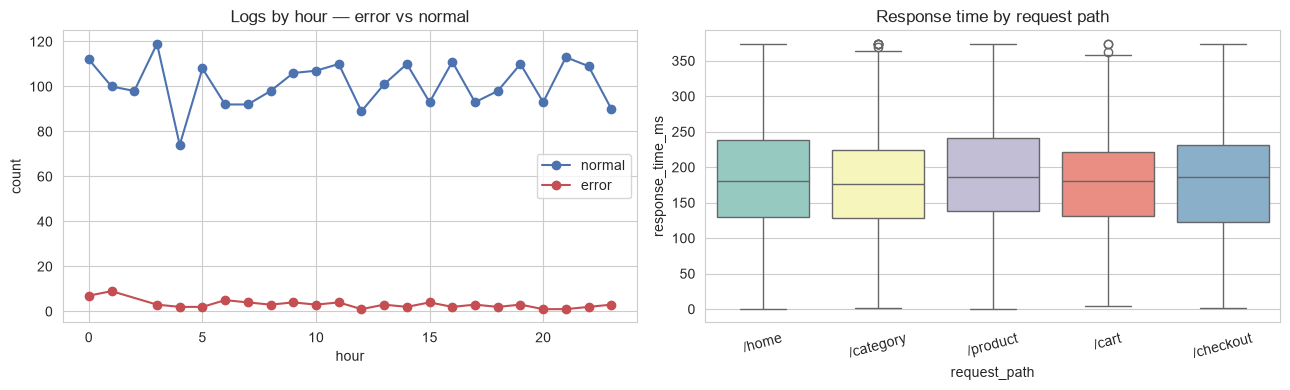

In [37]:
# 시나리오 3 — 탐색
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# (a) 시간대별 로그 수 — 에러 vs 정상 비교
hour_err = logs_clean.groupby(["hour", "is_error"]).size().reset_index(name="n")
for label, color in [(0, "#4C72B0"), (1, "#C44E52")]:
    part = hour_err[hour_err["is_error"] == label]
    axes[0].plot(part["hour"], part["n"], marker="o",
                 label="normal" if label == 0 else "error", color=color)
axes[0].set_title("Logs by hour — error vs normal")
axes[0].set_xlabel("hour"); axes[0].set_ylabel("count"); axes[0].legend()

# (b) 요청 경로별 응답 시간 분포
sns.boxplot(data=logs_clean, x="request_path", y="response_time_ms",
            order=["/home", "/category", "/product", "/cart", "/checkout"],
            ax=axes[1], palette="Set3")
axes[1].set_title("Response time by request path")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout(); plt.show()

In [38]:
# 시나리오 4 — 전달용 인터랙티브 차트
err_hour = (logs_clean.groupby(["hour", "is_error"]).size()
            .reset_index(name="count"))
err_hour["is_error"] = err_hour["is_error"].map({0: "normal", 1: "error"})

fig = px.bar(err_hour, x="hour", y="count", color="is_error",
             barmode="group", title="Hourly logs — error vs normal",
             color_discrete_map={"normal": "#4C72B0", "error": "#C44E52"})
fig.update_layout(width=900, height=420)
fig.show()

In [39]:
# 코드 퀴즈 — 모범 답안
joined = (orders_clean
          .merge(customers[["customer_id", "membership"]], on="customer_id")
          .merge(products[["product_id", "category"]], on="product_id"))
mean_amt = joined.groupby(["category", "membership"])["amount"].mean().reset_index()

fig = px.bar(mean_amt, x="category", y="amount", color="membership",
             barmode="group",
             category_orders={"membership": ["basic", "premium", "vip"]},
             title="Average amount by category × membership")
fig.update_layout(width=900, height=420)
fig.show()